In [1]:
import pandas as pd
import os
import numpy as np
import plotly.express as px
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PowerTransformer,MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV,LassoCV,LinearRegression,ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv('car_price.csv')

In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
df.shape

(8128, 13)

In [5]:
df.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object

In [6]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8123    False
8124    False
8125    False
8126     True
8127     True
Length: 8128, dtype: bool

In [7]:
df = df.drop_duplicates()

In [8]:
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1 bhp,90Nm@ 3500rpm,5.0
8122,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54 kmpl,1396 CC,88.73 bhp,219.7Nm@ 1500-2750rpm,5.0
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0


In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8121    False
8122    False
8123    False
8124    False
8125    False
Length: 6926, dtype: bool

In [10]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          208
engine           208
max_power        205
torque           209
seats            208
dtype: int64

In [11]:
df.shape

(6926, 13)

In [12]:
df['mileage'] = df['mileage'].str.extract(r'(\d+(?:\.\d+)?)').astype(float)
df.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [13]:
df.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine            object
max_power         object
torque            object
seats            float64
dtype: object

In [14]:
def make_numeric(arr):
    try:
        return float(arr.split()[0])
    except:
        pass


In [15]:
df['engine']=df['engine'].apply(make_numeric)

In [16]:
df['max_power'] = df['max_power'].apply(make_numeric)

In [17]:
df.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power        float64
torque            object
seats            float64
dtype: object

In [18]:
df['torque']

0                  190Nm@ 2000rpm
1             250Nm@ 1500-2500rpm
2           12.7@ 2,700(kgm@ rpm)
3        22.4 kgm at 1750-2750rpm
4           11.5@ 4,500(kgm@ rpm)
                  ...            
8121                90Nm@ 3500rpm
8122        219.7Nm@ 1500-2750rpm
8123             113.7Nm@ 4000rpm
8124    24@ 1,900-2,750(kgm@ rpm)
8125               190Nm@ 2000rpm
Name: torque, Length: 6926, dtype: object

In [19]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0


In [20]:
df.shape

(6926, 13)

In [21]:
def torque_nm(arr):
    
    try:
        s = ''
        for i in arr:
            if i in ['N',' ','@','k','n']:
                break
            else:
                s+=i
        return float(s)
    except:
        pass
    
    


In [22]:
df['Nm_torque'] = df['torque'].apply(torque_nm)

In [23]:
df.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power        float64
torque            object
seats            float64
Nm_torque        float64
dtype: object

In [24]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Nm_torque
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,190.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,250.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,12.7
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,22.4
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,11.5


In [25]:
df.isna().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          208
engine           208
max_power        206
torque           209
seats            208
Nm_torque        210
dtype: int64

In [26]:
df['torque']

0                  190Nm@ 2000rpm
1             250Nm@ 1500-2500rpm
2           12.7@ 2,700(kgm@ rpm)
3        22.4 kgm at 1750-2750rpm
4           11.5@ 4,500(kgm@ rpm)
                  ...            
8121                90Nm@ 3500rpm
8122        219.7Nm@ 1500-2750rpm
8123             113.7Nm@ 4000rpm
8124    24@ 1,900-2,750(kgm@ rpm)
8125               190Nm@ 2000rpm
Name: torque, Length: 6926, dtype: object

In [27]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Nm_torque
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,190.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,250.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,12.7
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,22.4
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,11.5


In [28]:
df['torque'] = df['torque'].str.replace(',','')
df['torque'] = df['torque'].str.replace(' kgm at','@')


In [29]:
def rpm(arr):
    try:
        s = ''
        for i in arr.split(' ')[1]:
            if i.isnumeric() or i=='-':
                s+=i
        return s
    except:
        pass

In [30]:
df['rpm'] = df['torque'].apply(rpm)

In [31]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Nm_torque,rpm
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,190.0,2000
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,250.0,1500-2500
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,12.7@ 2700(kgm@ rpm),5.0,12.7,2700
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4@ 1750-2750rpm,5.0,22.4,1750-2750
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,11.5@ 4500(kgm@ rpm),5.0,11.5,4500


In [32]:
df['rpm'].isna().sum()

np.int64(213)

In [33]:
df['min_rpm'] = df['rpm'].str.split('-').str[0]
df['max_rpm'] = df['rpm'].str.split('-').str[-1]


In [34]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Nm_torque,rpm,min_rpm,max_rpm
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,190.0,2000,2000,2000
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,250.0,1500-2500,1500,2500
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,12.7@ 2700(kgm@ rpm),5.0,12.7,2700,2700,2700
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4@ 1750-2750rpm,5.0,22.4,1750-2750,1750,2750
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,11.5@ 4500(kgm@ rpm),5.0,11.5,4500,4500,4500


In [35]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Nm_torque,rpm,min_rpm,max_rpm
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,190.0,2000,2000,2000
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,250.0,1500-2500,1500,2500
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,12.7@ 2700(kgm@ rpm),5.0,12.7,2700,2700,2700
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4@ 1750-2750rpm,5.0,22.4,1750-2750,1750,2750
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,11.5@ 4500(kgm@ rpm),5.0,11.5,4500,4500,4500


In [36]:
df.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power        float64
torque            object
seats            float64
Nm_torque        float64
rpm               object
min_rpm           object
max_rpm           object
dtype: object

In [37]:
def make_int(s):
    try:
        return int(s)
    except:
        pass

In [38]:
df['min_rpm'] = df['min_rpm'].apply(make_int)
df['max_rpm'] = df['max_rpm'].apply(make_int)


In [39]:
df.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power        float64
torque            object
seats            float64
Nm_torque        float64
rpm               object
min_rpm          float64
max_rpm          float64
dtype: object

In [40]:
df.drop(columns=['torque','rpm'],inplace=True)

In [41]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,Nm_torque,min_rpm,max_rpm
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,190.0,2000.0,2000.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,250.0,1500.0,2500.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,12.7,2700.0,2700.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,22.4,1750.0,2750.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,11.5,4500.0,4500.0


In [42]:
df.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power        float64
seats            float64
Nm_torque        float64
min_rpm          float64
max_rpm          float64
dtype: object

In [43]:
df.corr(numeric_only=True)

,year,selling_price,km_driven,mileage,engine,max_power,seats,Nm_torque,min_rpm,max_rpm
year,1.000000,0.433076,-0.377003,0.366694,-0.019074,0.159688,0.023632,0.262932,-0.016692,-0.016428
selling_price,0.433076,1.000000,-0.165620,-0.108344,0.442857,0.691536,0.158111,0.616910,-0.002131,-0.001315
km_driven,-0.377003,-0.165620,1.000000,-0.196494,0.253339,0.041777,0.207957,0.048924,0.012343,0.012682
mileage,0.366694,-0.108344,-0.196494,1.000000,-0.578483,-0.378609,-0.459624,-0.132743,-0.022978,-0.023624
engine,-0.019074,0.442857,0.253339,-0.578483,1.000000,0.683506,0.657798,0.611612,0.011725,0.013042
max_power,0.159688,0.691536,0.041777,-0.378609,0.683506,1.000000,0.259028,0.743442,0.038520,0.039636
seats,0.023632,0.158111,0.207957,-0.459624,0.657798,0.259028,1.000000,0.322164,-0.009008,-0.008091
Nm_torque,0.262932,0.616910,0.048924,-0.132743,0.611612,0.743442,0.322164,1.000000,0.014620,0.015665
min_rpm,-0.016692,-0.002131,0.012343,-0.022978,0.011725,0.038520,-0.009008,0.014620,1.000000,0.999997
max_rpm,-0.016428,-0.001315,0.012682,-0.023624,0.013042,0.039636,-0.008091,0.015665,0.999997,1.000000


In [44]:
df['torque_ratio'] = df['Nm_torque']/((df['max_rpm']+df['max_rpm'])/2)
df.corr(numeric_only=True)

,year,selling_price,km_driven,mileage,engine,max_power,seats,Nm_torque,min_rpm,max_rpm,torque_ratio
year,1.000000,0.433076,-0.377003,0.366694,-0.019074,0.159688,0.023632,0.262932,-0.016692,-0.016428,0.211637
selling_price,0.433076,1.000000,-0.165620,-0.108344,0.442857,0.691536,0.158111,0.616910,-0.002131,-0.001315,0.522375
km_driven,-0.377003,-0.165620,1.000000,-0.196494,0.253339,0.041777,0.207957,0.048924,0.012343,0.012682,0.090868
mileage,0.366694,-0.108344,-0.196494,1.000000,-0.578483,-0.378609,-0.459624,-0.132743,-0.022978,-0.023624,0.032404
engine,-0.019074,0.442857,0.253339,-0.578483,1.000000,0.683506,0.657798,0.611612,0.011725,0.013042,0.525773
max_power,0.159688,0.691536,0.041777,-0.378609,0.683506,1.000000,0.259028,0.743442,0.038520,0.039636,0.573701
seats,0.023632,0.158111,0.207957,-0.459624,0.657798,0.259028,1.000000,0.322164,-0.009008,-0.008091,0.292419
Nm_torque,0.262932,0.616910,0.048924,-0.132743,0.611612,0.743442,0.322164,1.000000,0.014620,0.015665,0.909303
min_rpm,-0.016692,-0.002131,0.012343,-0.022978,0.011725,0.038520,-0.009008,0.014620,1.000000,0.999997,-0.027301
max_rpm,-0.016428,-0.001315,0.012682,-0.023624,0.013042,0.039636,-0.008091,0.015665,0.999997,1.000000,-0.026742


In [45]:
df['car_age'] = 2025 - df['year']

In [46]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,Nm_torque,min_rpm,max_rpm,torque_ratio,car_age
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,190.0,2000.0,2000.0,0.095000,11
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,250.0,1500.0,2500.0,0.100000,11
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,12.7,2700.0,2700.0,0.004704,19
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,22.4,1750.0,2750.0,0.008145,15
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,11.5,4500.0,4500.0,0.002556,18


In [47]:
df.drop(columns=['year','Nm_torque','min_rpm','max_rpm'],inplace=True)

In [48]:
df.head()

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,torque_ratio,car_age
0,Maruti Swift Dzire VDI,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,0.095000,11
1,Skoda Rapid 1.5 TDI Ambition,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,0.100000,11
2,Honda City 2017-2020 EXi,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,0.004704,19
3,Hyundai i20 Sportz Diesel,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,0.008145,15
4,Maruti Swift VXI BSIII,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,0.002556,18


In [49]:
df.isna().sum()

name               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          208
engine           208
max_power        206
seats            208
torque_ratio     367
car_age            0
dtype: int64

In [50]:
from sklearn.impute import KNNImputer

In [51]:
imputer = KNNImputer()
cols=df[['mileage','engine','max_power','torque_ratio','seats']]
imputed =imputer.fit_transform(cols)
imputed[0:,0]

array([23.4 , 21.14, 17.7 , ..., 18.5 , 16.8 , 19.3 ])

In [52]:
imputed.shape

(6926, 5)

In [53]:
def imputations(imputed,df):
    cols=['mileage','engine','max_power','torque_ratio','seats']
    n=len(cols)
    for iter in range(n):
        df[cols[iter]]=imputed[0:,iter]
    return df
df=imputations(imputed,df)
df.head()

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,torque_ratio,car_age
0,Maruti Swift Dzire VDI,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,0.095000,11
1,Skoda Rapid 1.5 TDI Ambition,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,0.100000,11
2,Honda City 2017-2020 EXi,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,0.004704,19
3,Hyundai i20 Sportz Diesel,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,0.008145,15
4,Maruti Swift VXI BSIII,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,0.002556,18


In [54]:
df.isna().sum()

name             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
torque_ratio     0
car_age          0
dtype: int64

In [55]:
df.corr(numeric_only=True)

,selling_price,km_driven,mileage,engine,max_power,seats,torque_ratio,car_age
selling_price,1.000000,-0.165620,-0.107261,0.439347,0.686077,0.156714,0.506436,-0.433076
km_driven,-0.165620,1.000000,-0.194545,0.250916,0.041270,0.205956,0.095983,0.377003
mileage,-0.107261,-0.194545,1.000000,-0.577359,-0.375579,-0.459834,0.017207,-0.345307
engine,0.439347,0.250916,-0.577359,1.000000,0.683768,0.657020,0.529485,0.017948
max_power,0.686077,0.041270,-0.375579,0.683768,1.000000,0.256765,0.561526,-0.151070
seats,0.156714,0.205956,-0.459834,0.657020,0.256765,1.000000,0.304791,-0.022250
torque_ratio,0.506436,0.095983,0.017207,0.529485,0.561526,0.304791,1.000000,-0.190408
car_age,-0.433076,0.377003,-0.345307,0.017948,-0.151070,-0.022250,-0.190408,1.000000


In [56]:
#df.drop(columns=['torque'])

In [57]:
X=df.drop(columns={'selling_price'})

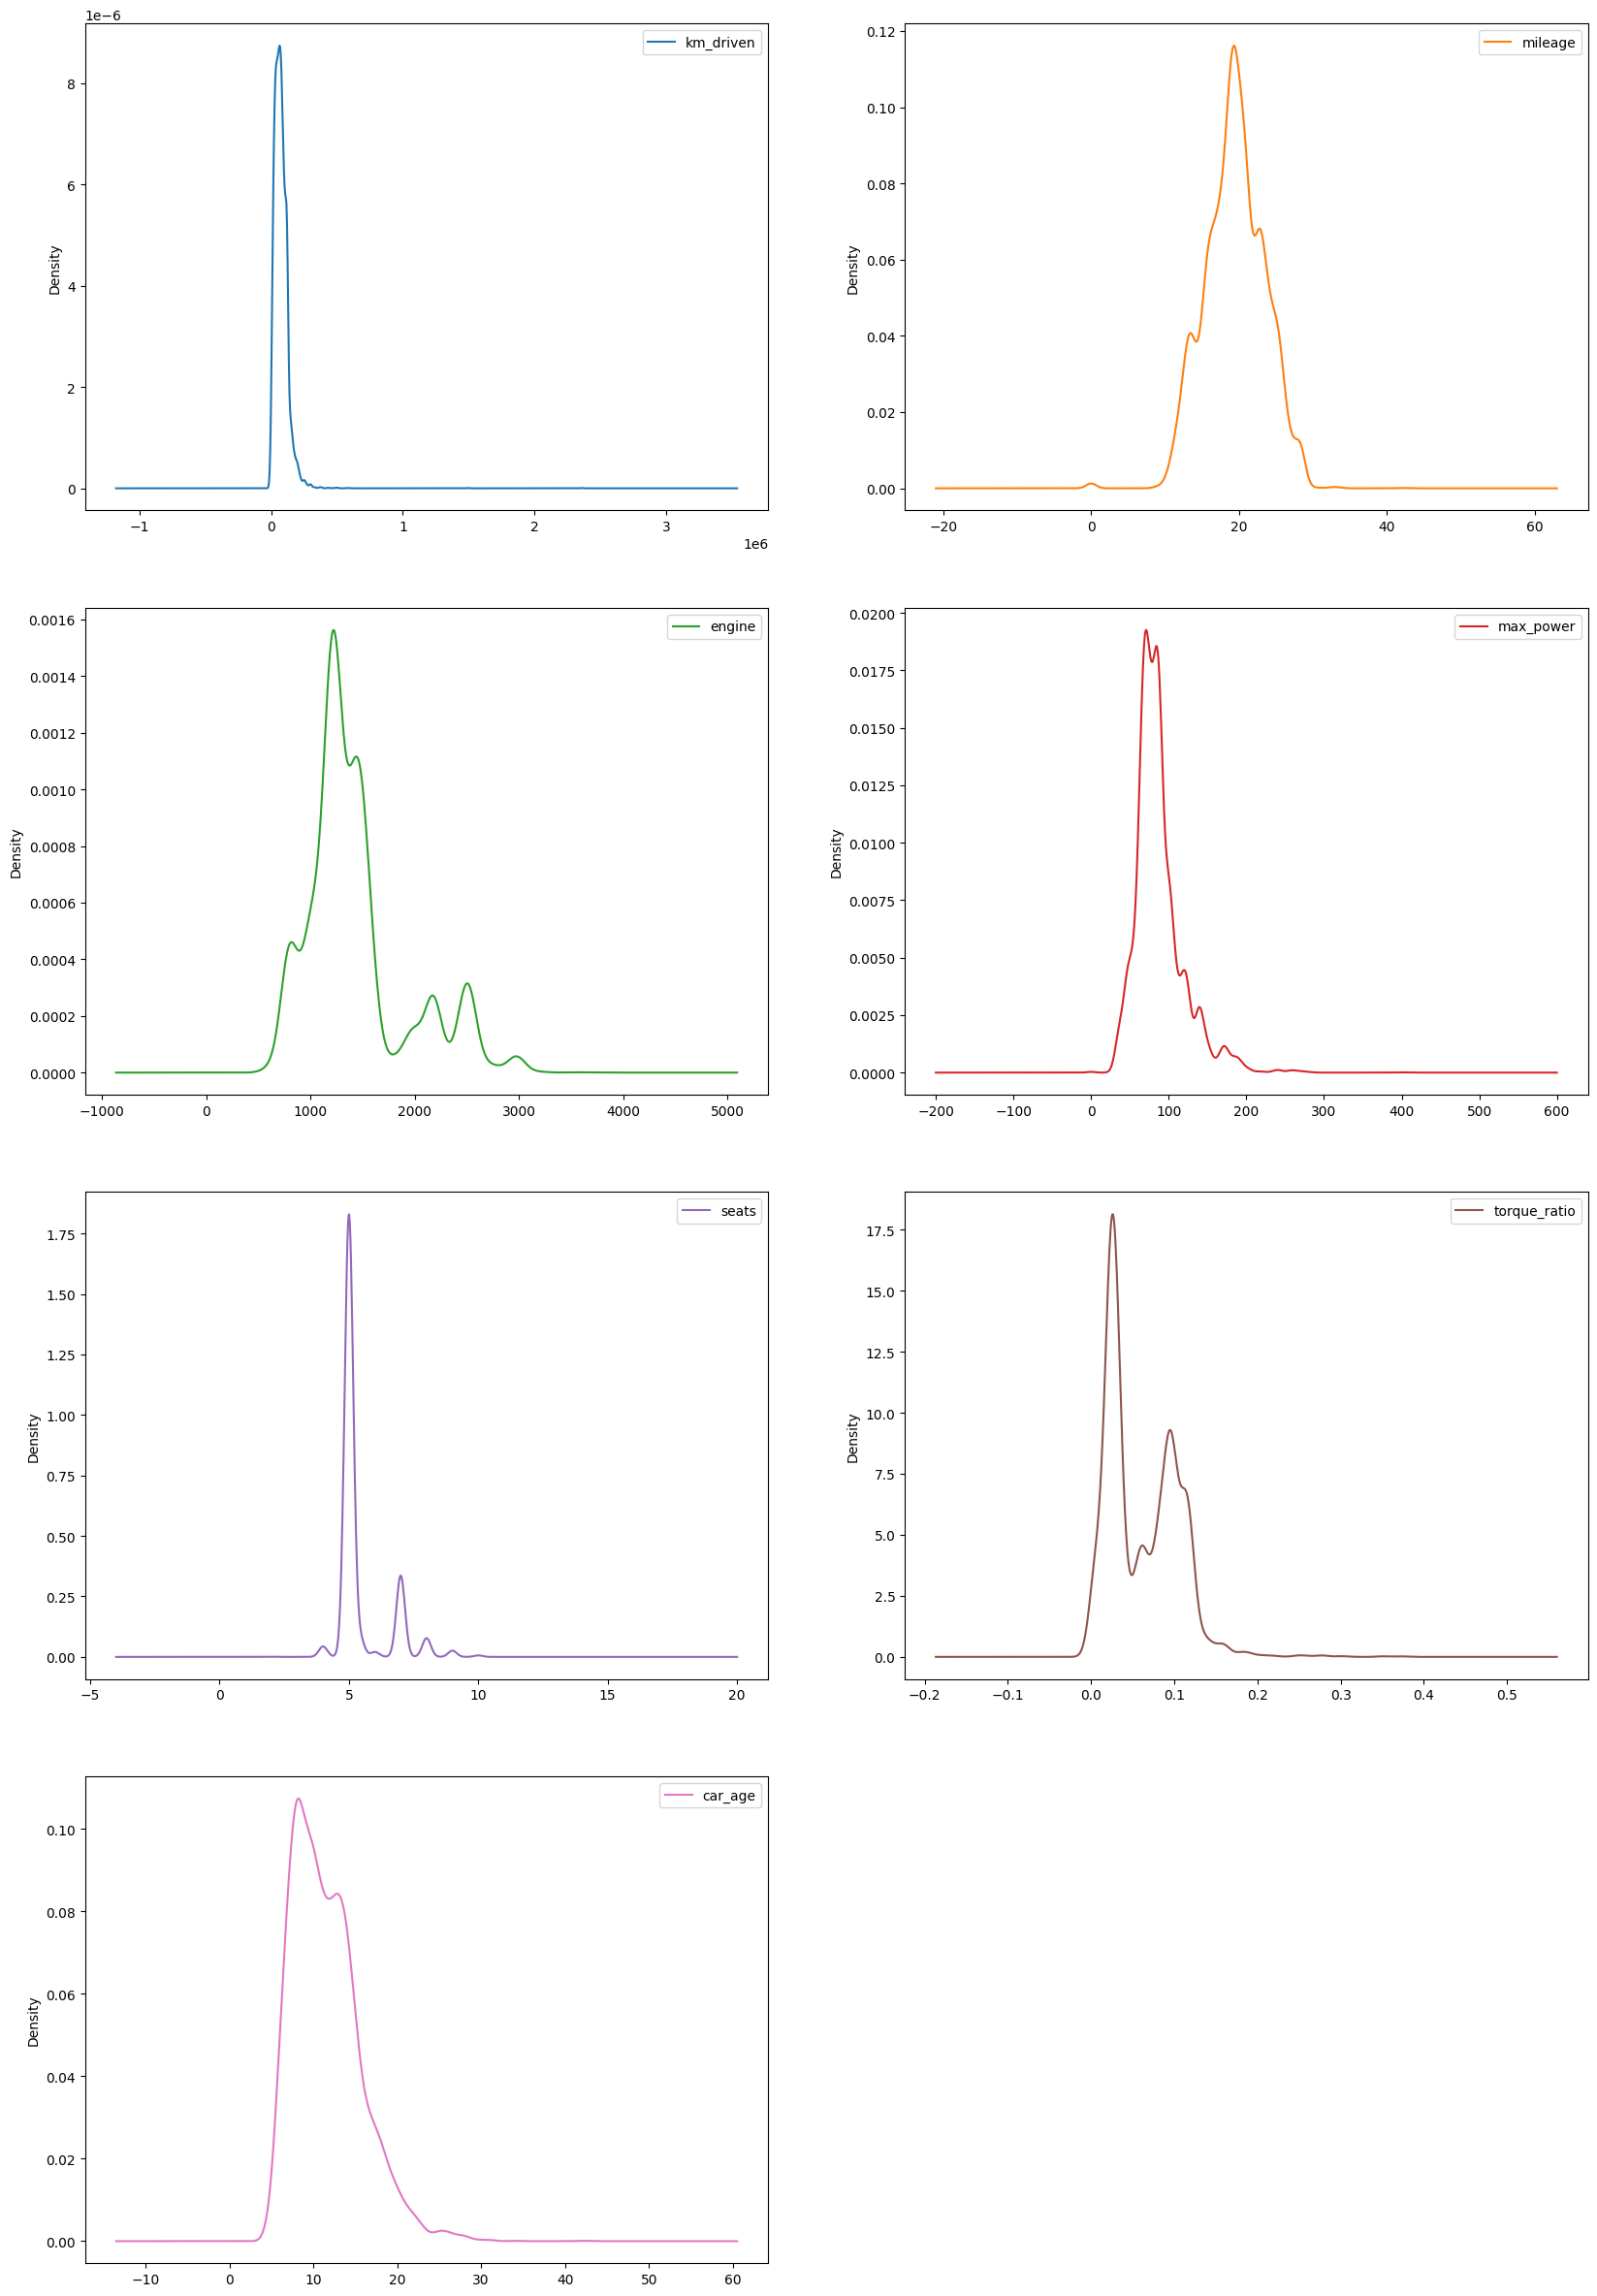

<Figure size 640x480 with 0 Axes>

In [58]:
import matplotlib.pyplot as plt
# Now Check Distribution of our data 
def distributions(X):
    num_cols=X.select_dtypes(include='number')
    num_cols.plot(
        kind='density',
        subplots=True,
        layout=(4,2),
        figsize=(20,30),
        sharex=False,
        sharey=False
    )
    plt.show()
    plt.tight_layout()
distributions(X)

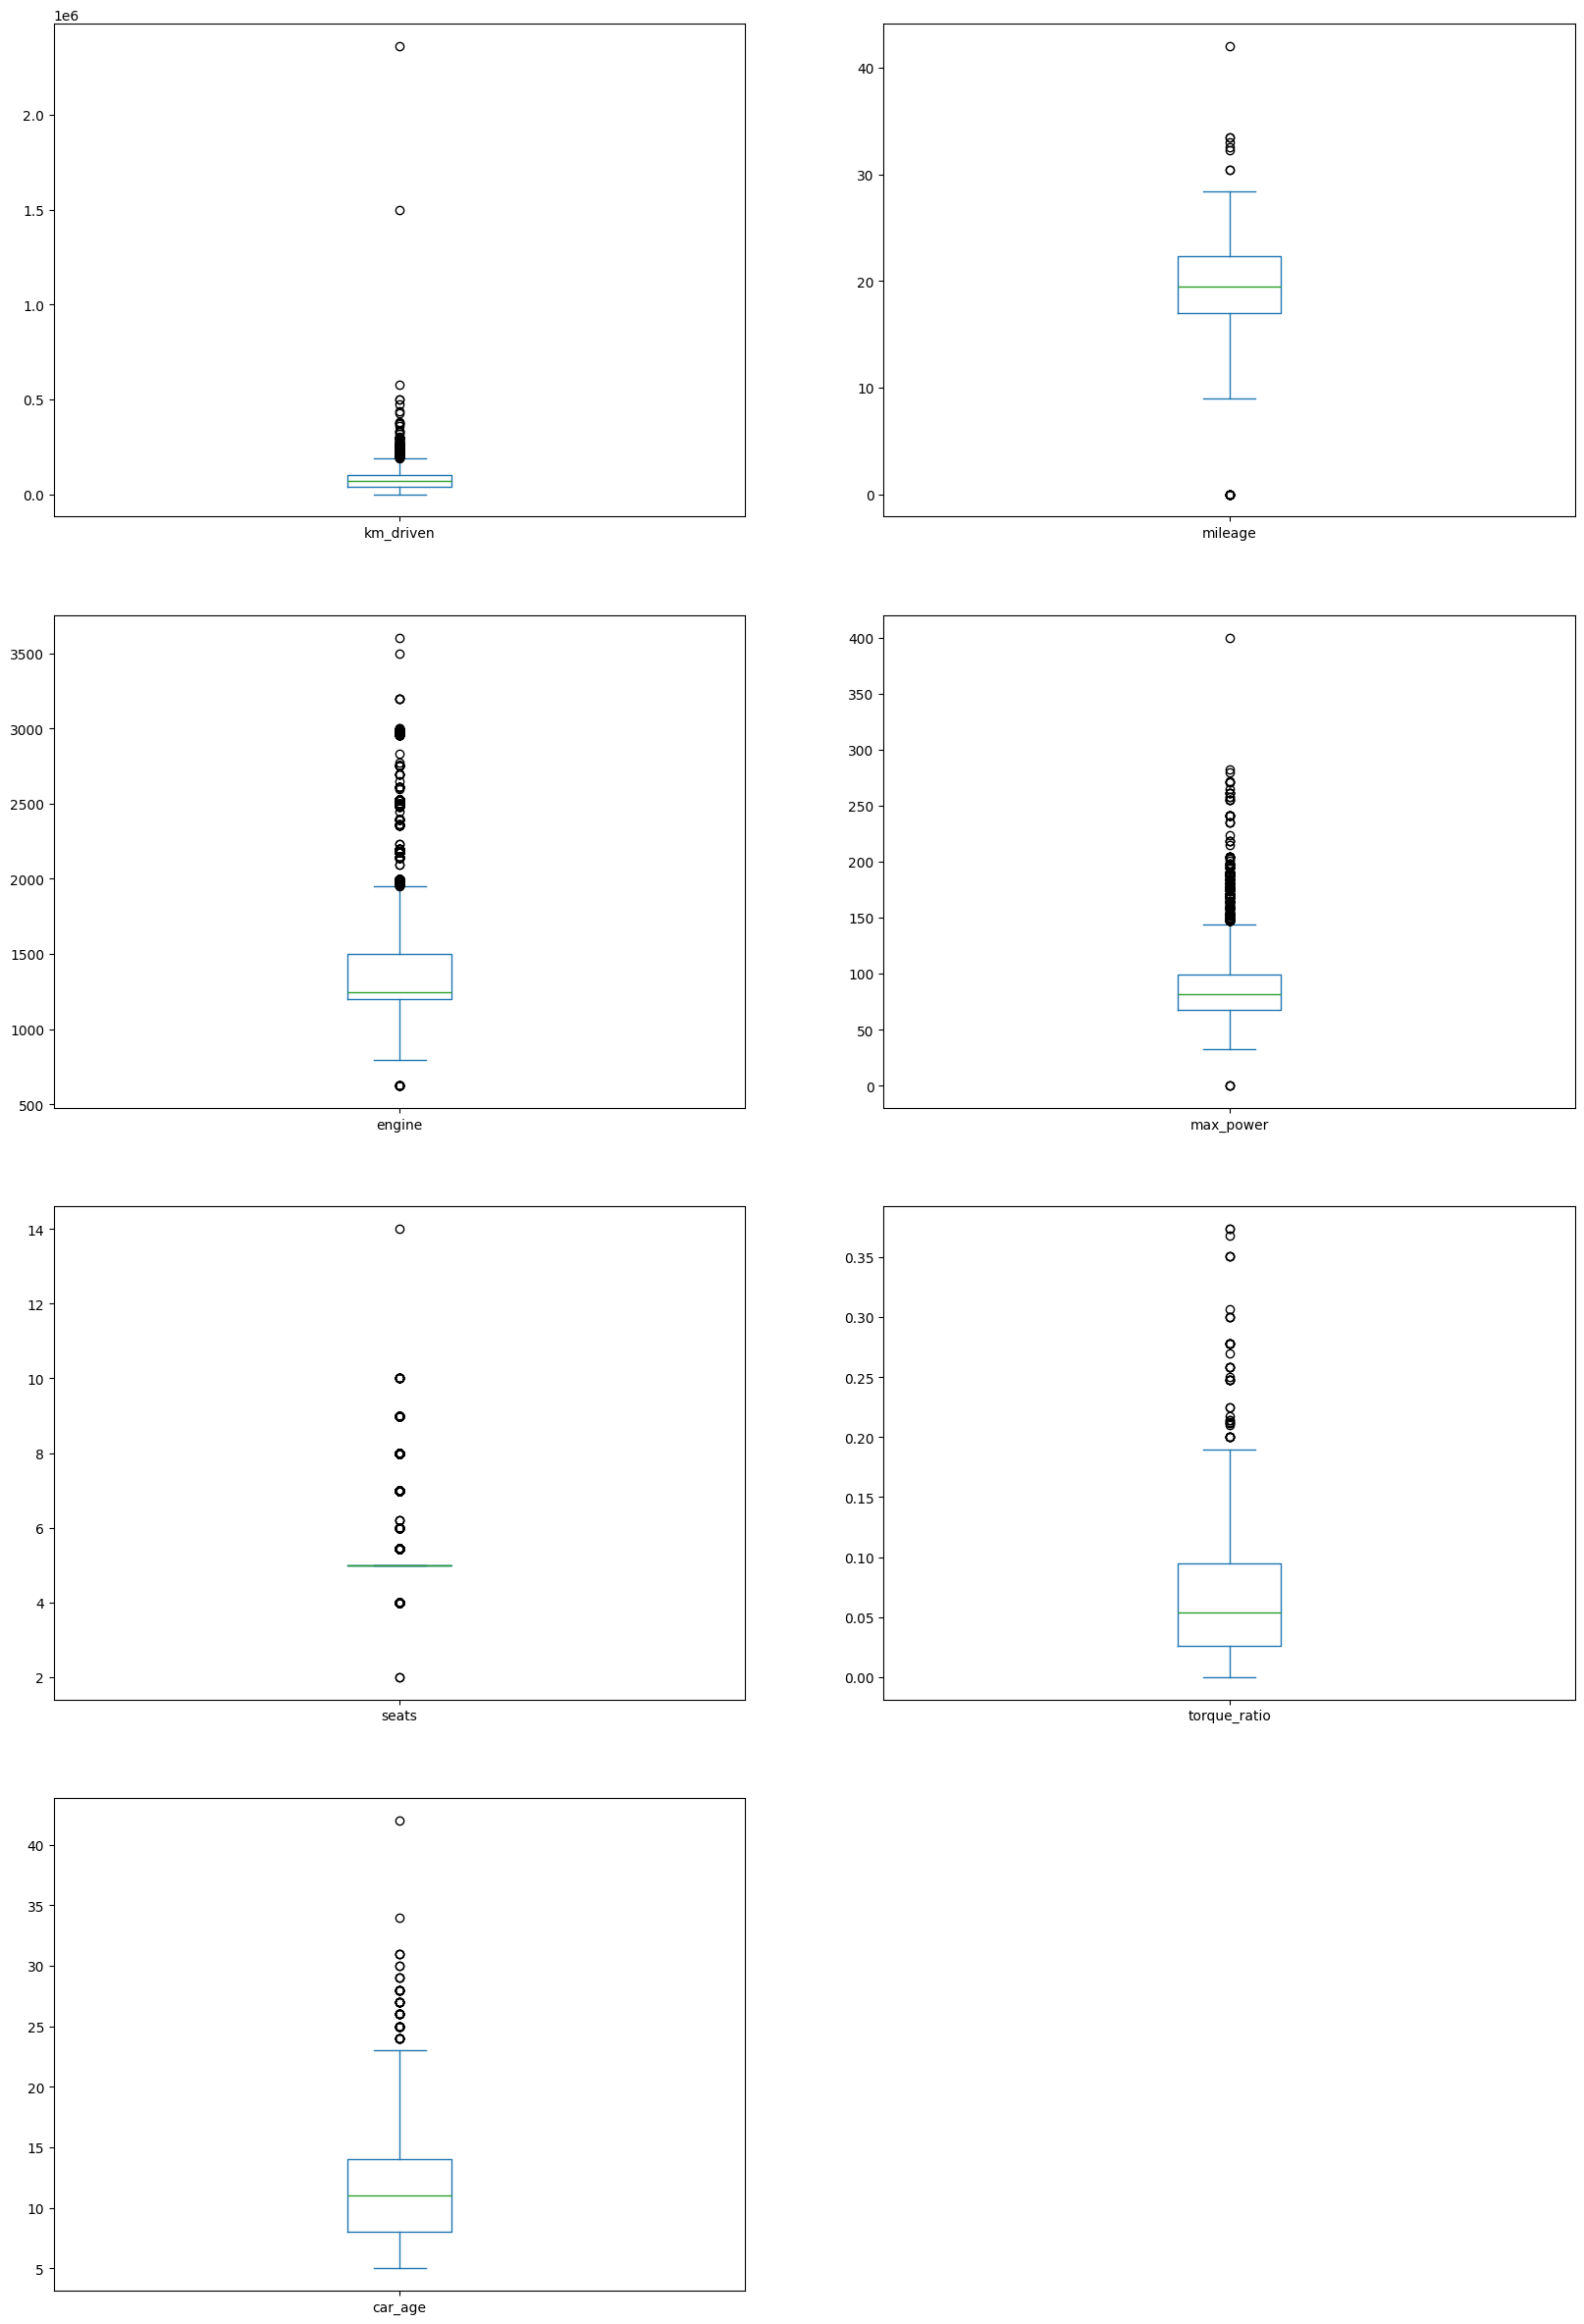

<Figure size 640x480 with 0 Axes>

In [59]:
def outliers(X):
    num_cols=X.select_dtypes(include='number')
    num_cols.plot(
        kind='box',
        subplots=True,
        layout=(4,2),
        figsize=(20,30),
        sharex=False,
        sharey=False
    )
    plt.show()
    plt.tight_layout()
outliers(X)

In [60]:
def transformations(df):
    X=df.drop(columns={'selling_price'})
    num_cols=X.select_dtypes(include='number')
    transformer=PowerTransformer(method='yeo-johnson')
    num_cols_new=transformer.fit_transform(num_cols)
    return num_cols_new
transform_arr=transformations(df)
transform_arr[0:,0]

array([1.34590913, 0.99727963, 1.27426897, ..., 0.84749356, 0.9826722 ,
       0.99727963])

In [61]:
def after_transformation(transform_arr,df):
    X=df.drop(columns={'selling_price'})
    num_cols=X.select_dtypes(include='number')
    names=X.select_dtypes(include='number').columns.values
    for iter in range(len(names)):
        num_cols[names[iter]] = transform_arr[0:,iter]
    return num_cols
trans_df=after_transformation(transform_arr,df)
trans_df.head()

,km_driven,mileage,engine,max_power,seats,torque_ratio,car_age
0,1.345909,0.993170,-0.208047,-0.366268,-0.396243,0.907567,0.041788
1,0.997280,0.403828,0.386320,0.645711,-0.396243,0.998952,0.041788
2,1.274269,-0.465478,0.384244,-0.211487,-0.396243,-1.657120,1.594566
3,1.097397,0.887872,0.163148,0.216571,-0.396243,-1.516653,0.938325
4,0.997280,-0.857318,-0.075570,0.155485,-0.396243,-1.747080,1.446643


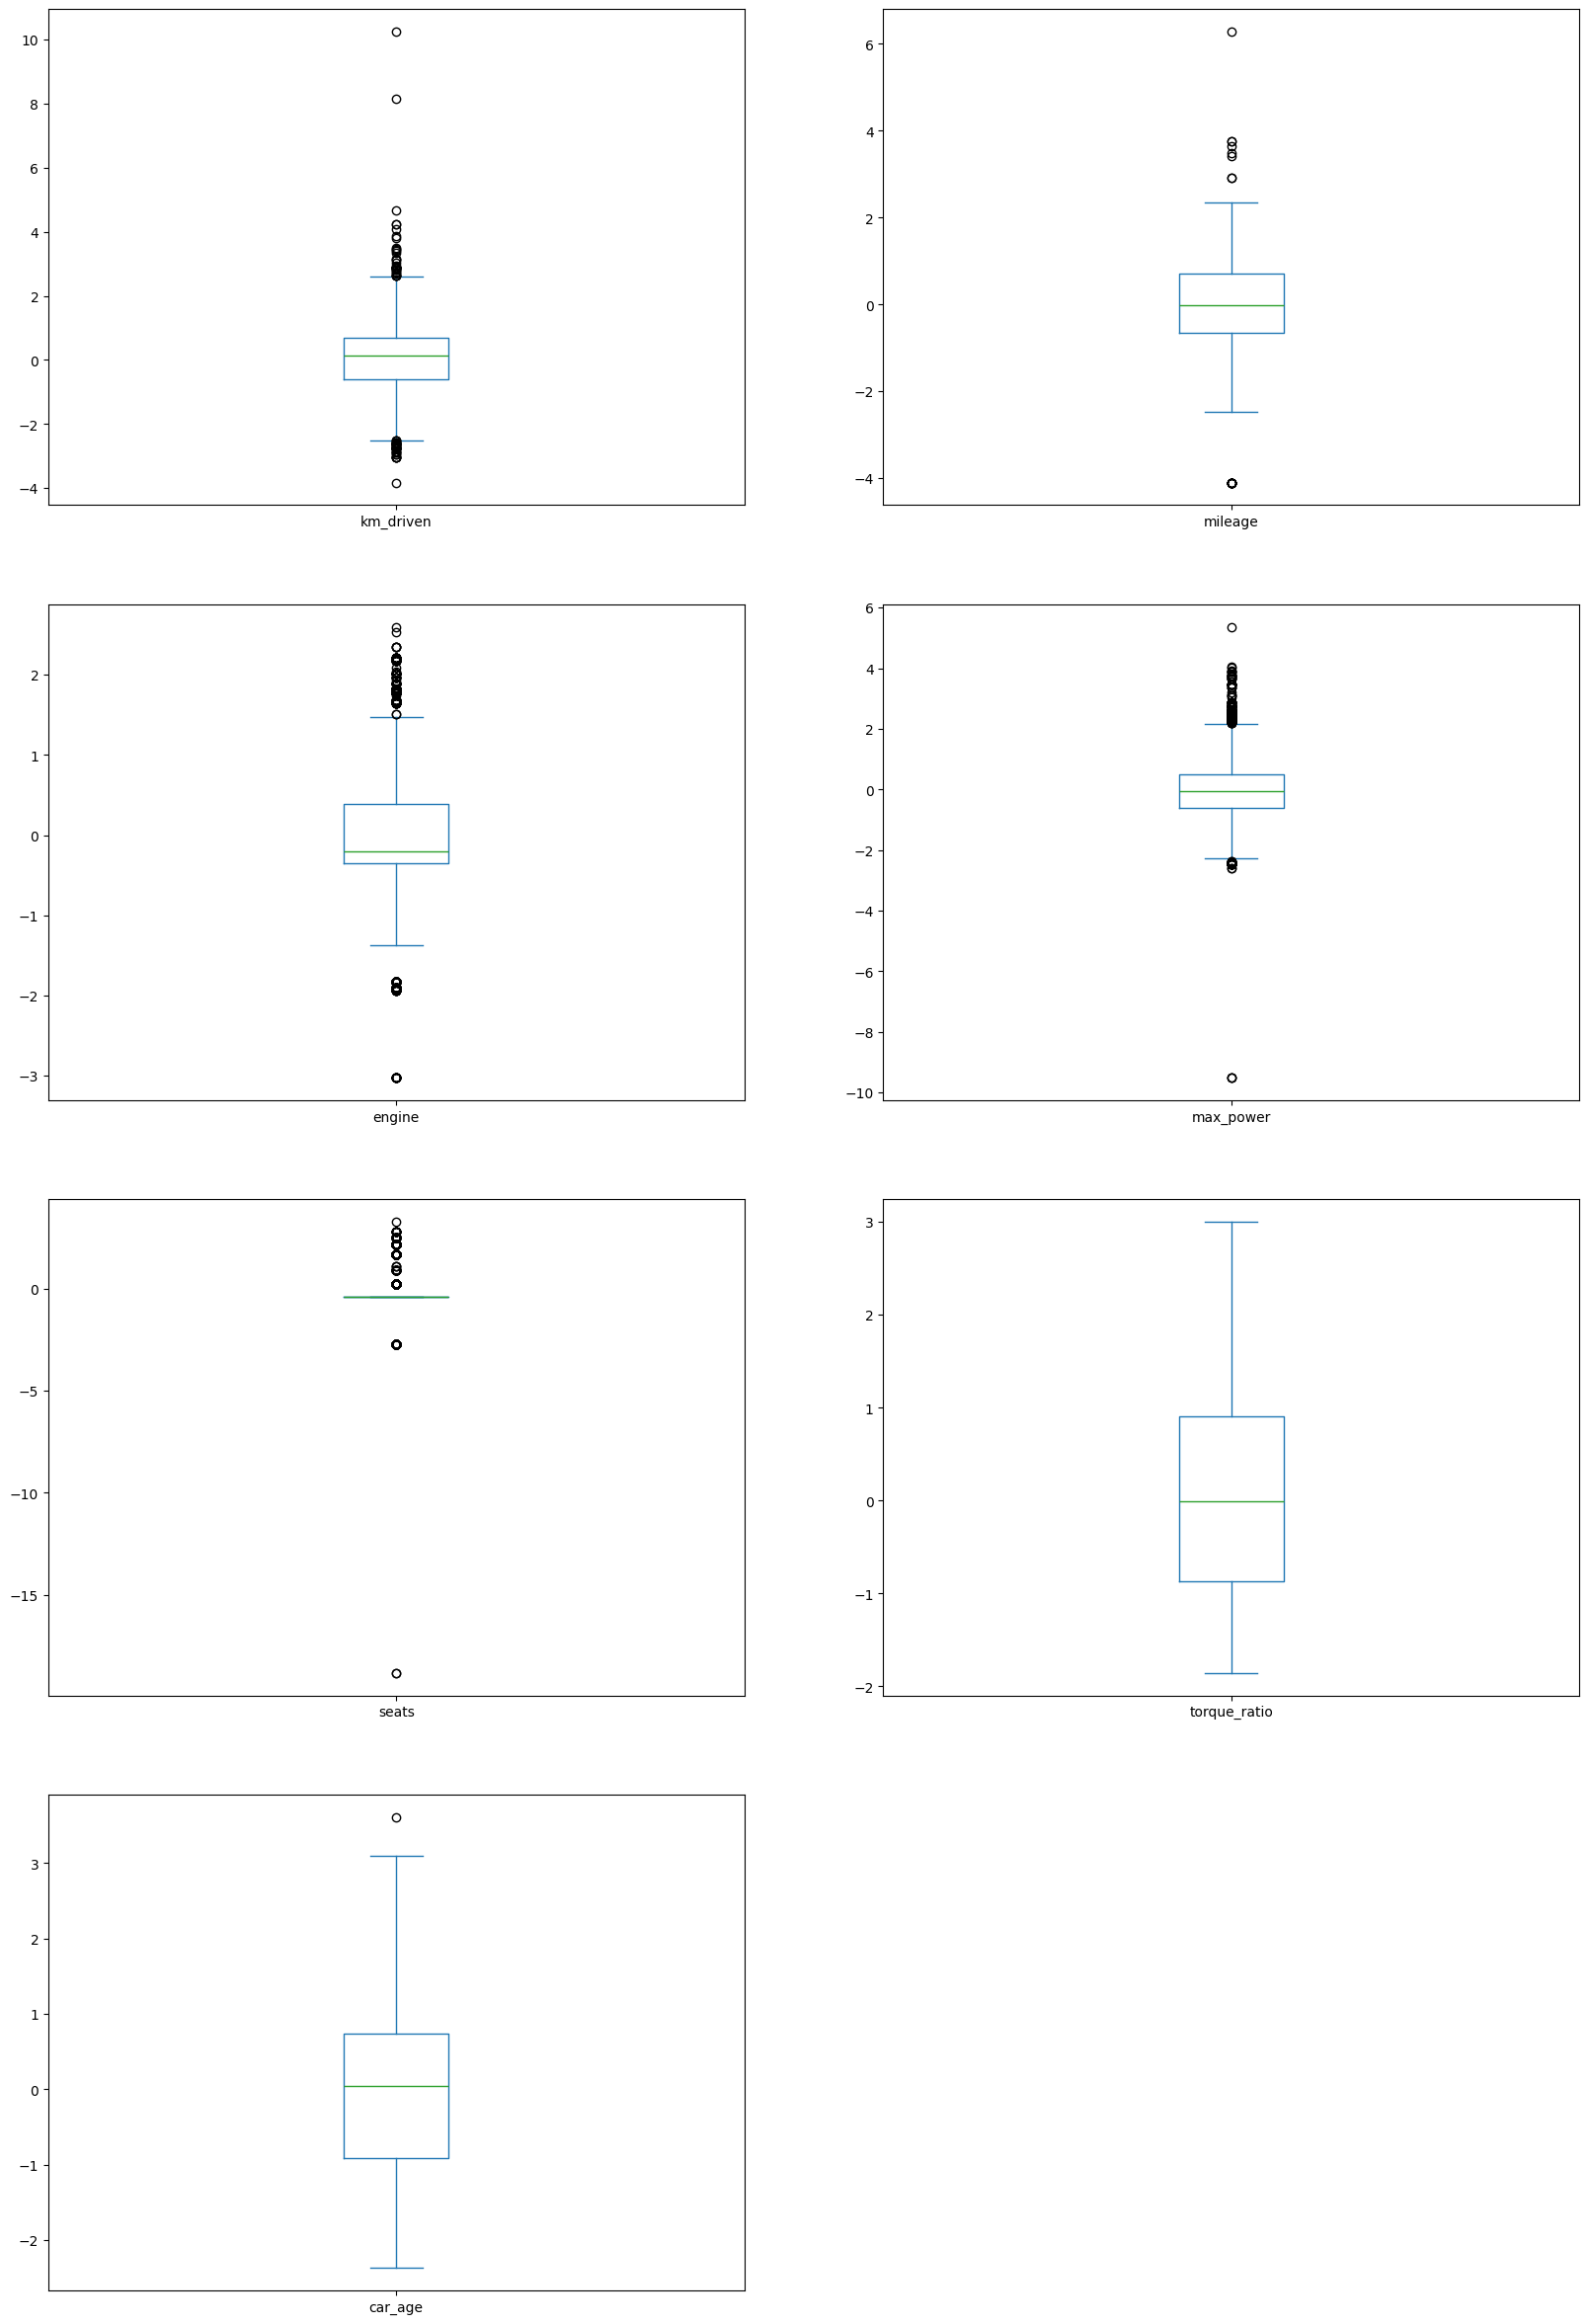

<Figure size 640x480 with 0 Axes>

In [62]:
outliers(trans_df)

In [63]:
# Lets scale our data using standard sacler
def scaling(trans_df):
    num_cols=trans_df.select_dtypes(include='number')
    scaler=StandardScaler()
    scaled_arr=scaler.fit_transform(num_cols)
    return scaled_arr
scaled_arr=scaling(trans_df)
scaled_arr.shape

(6926, 7)

In [64]:
def after_scaling(scaled_arr,trans_df):
    num_cols=trans_df.select_dtypes(include='number')
    names=trans_df.select_dtypes(include='number').columns.values
    for iter in range(len(names)):
        num_cols[names[iter]] = scaled_arr[0:,iter]
    return num_cols
scaled_df=after_scaling(scaled_arr,trans_df)
scaled_df.head()

,km_driven,mileage,engine,max_power,seats,torque_ratio,car_age
0,1.345909,0.993170,-0.208047,-0.366268,-0.396243,0.907567,0.041788
1,0.997280,0.403828,0.386320,0.645711,-0.396243,0.998952,0.041788
2,1.274269,-0.465478,0.384244,-0.211487,-0.396243,-1.657120,1.594566
3,1.097397,0.887872,0.163148,0.216571,-0.396243,-1.516653,0.938325
4,0.997280,-0.857318,-0.075570,0.155485,-0.396243,-1.747080,1.446643


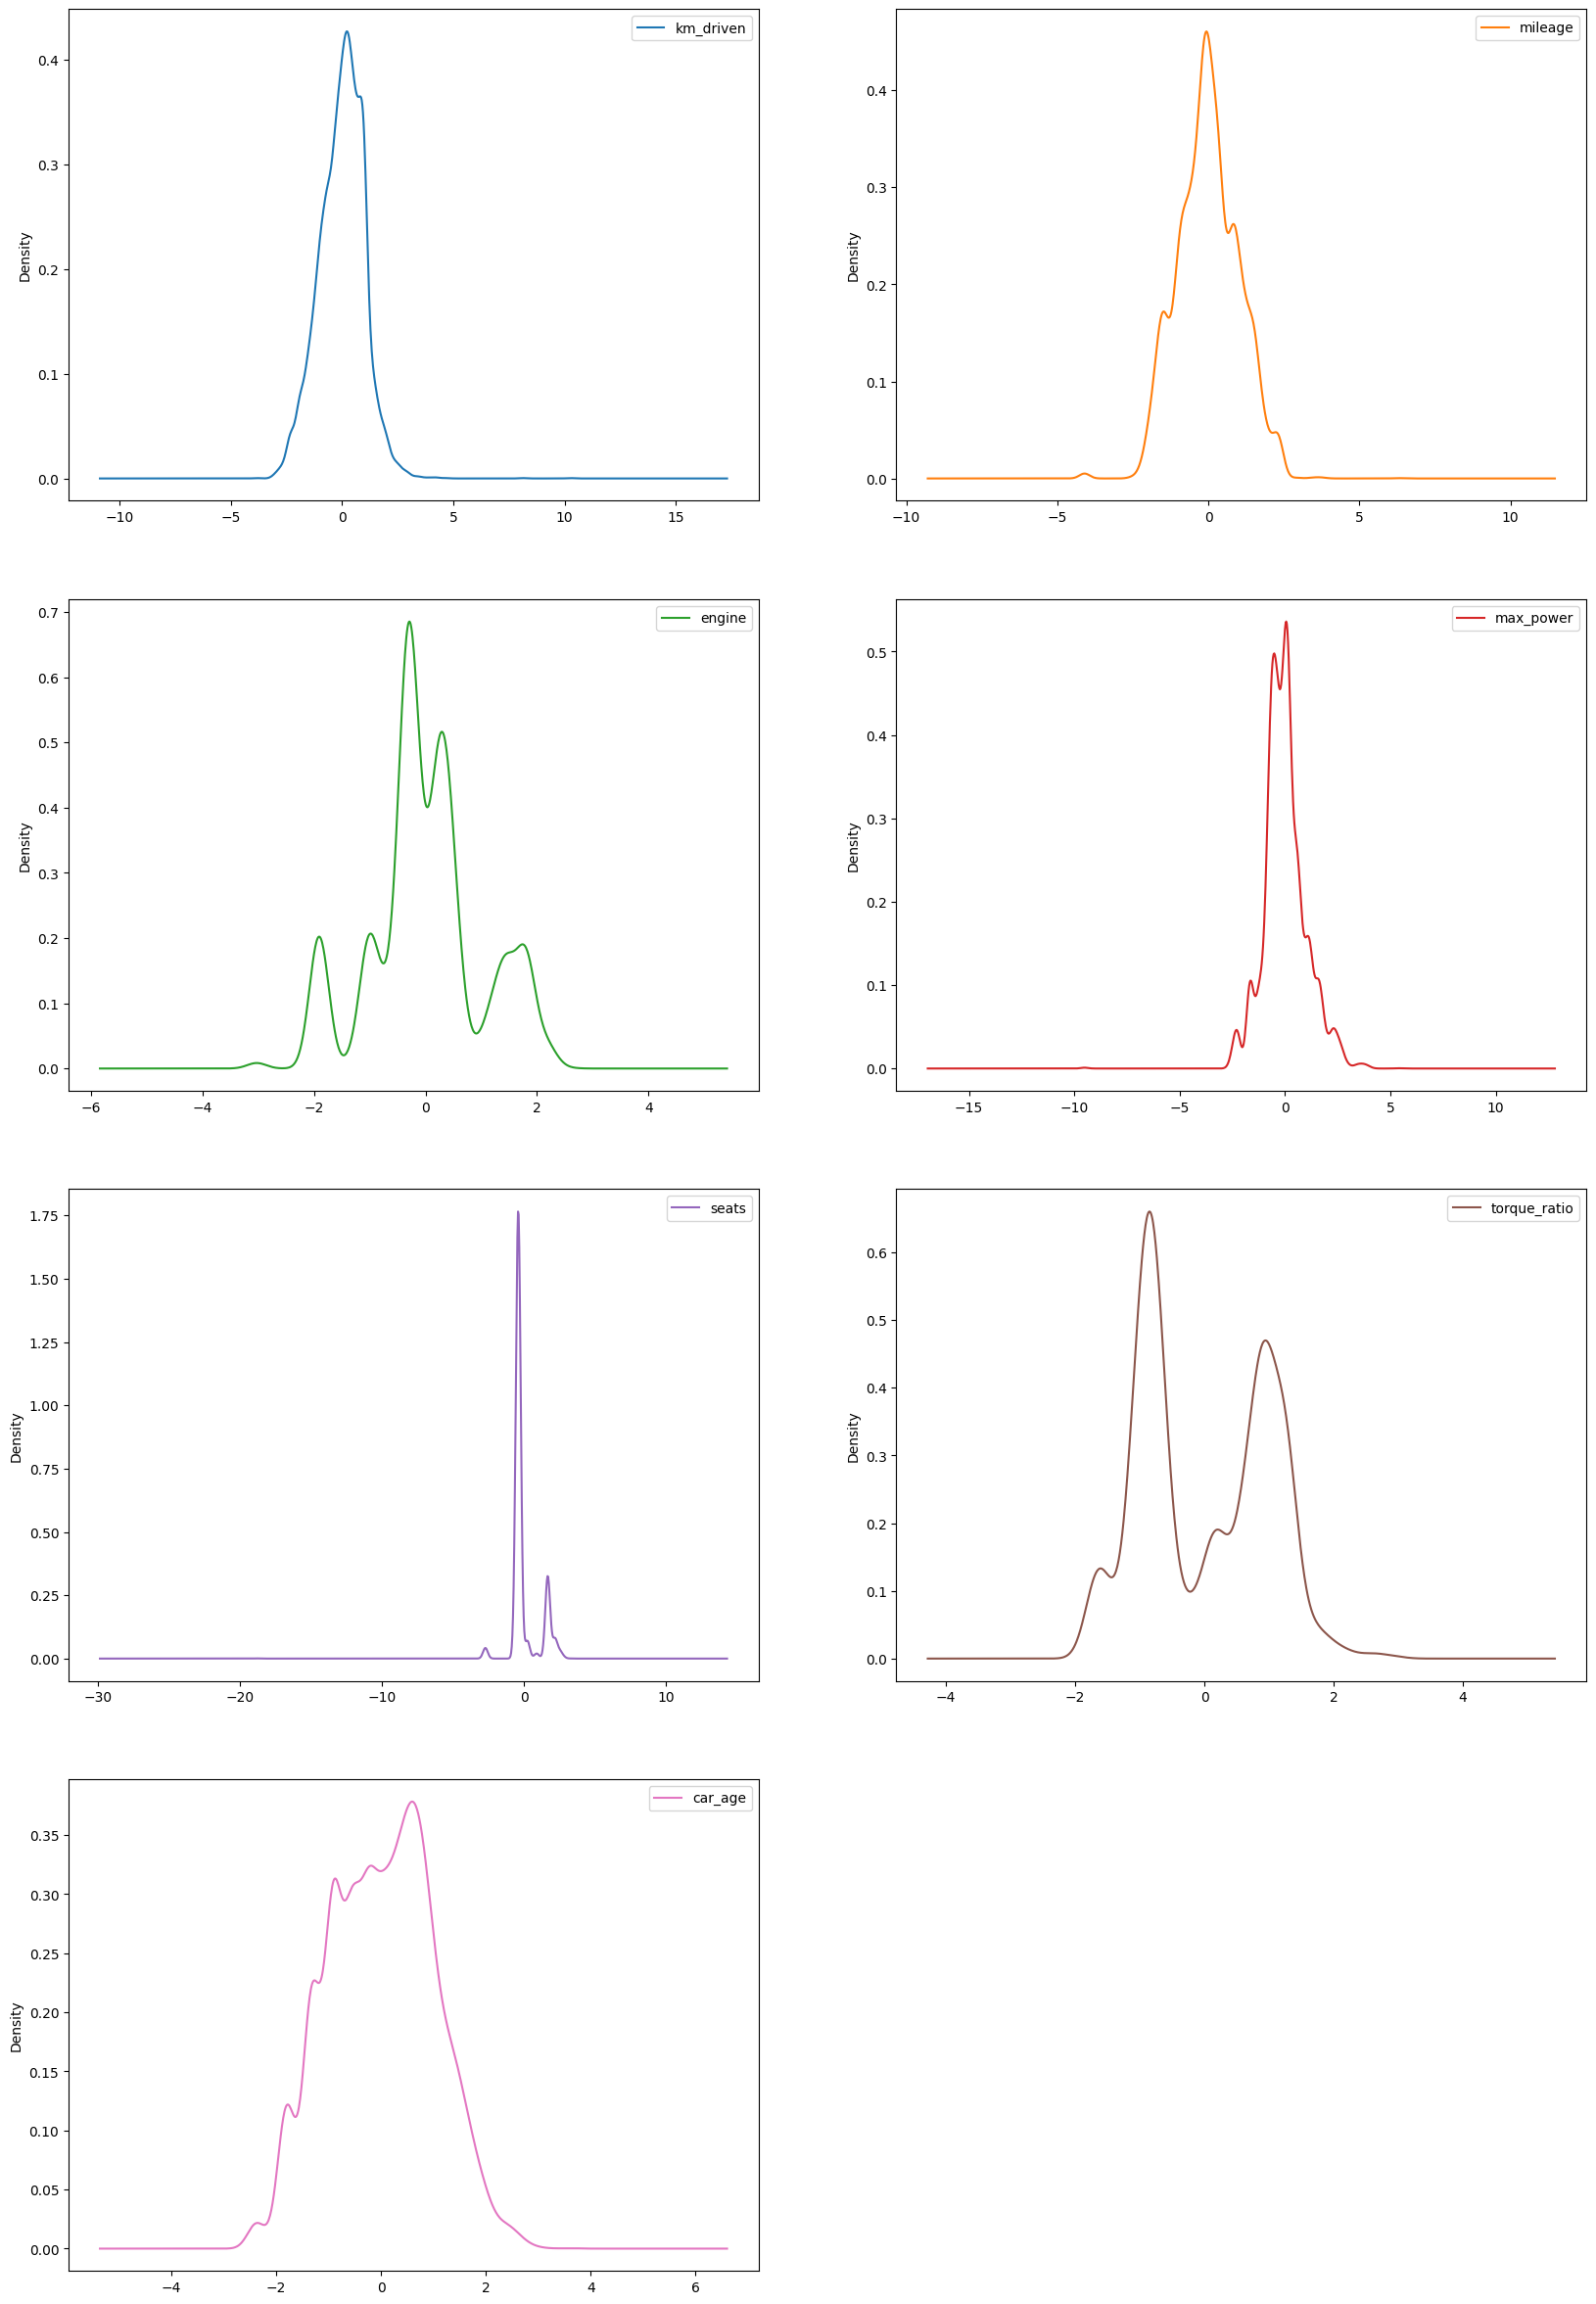

<Figure size 640x480 with 0 Axes>

In [65]:
distributions(scaled_df)

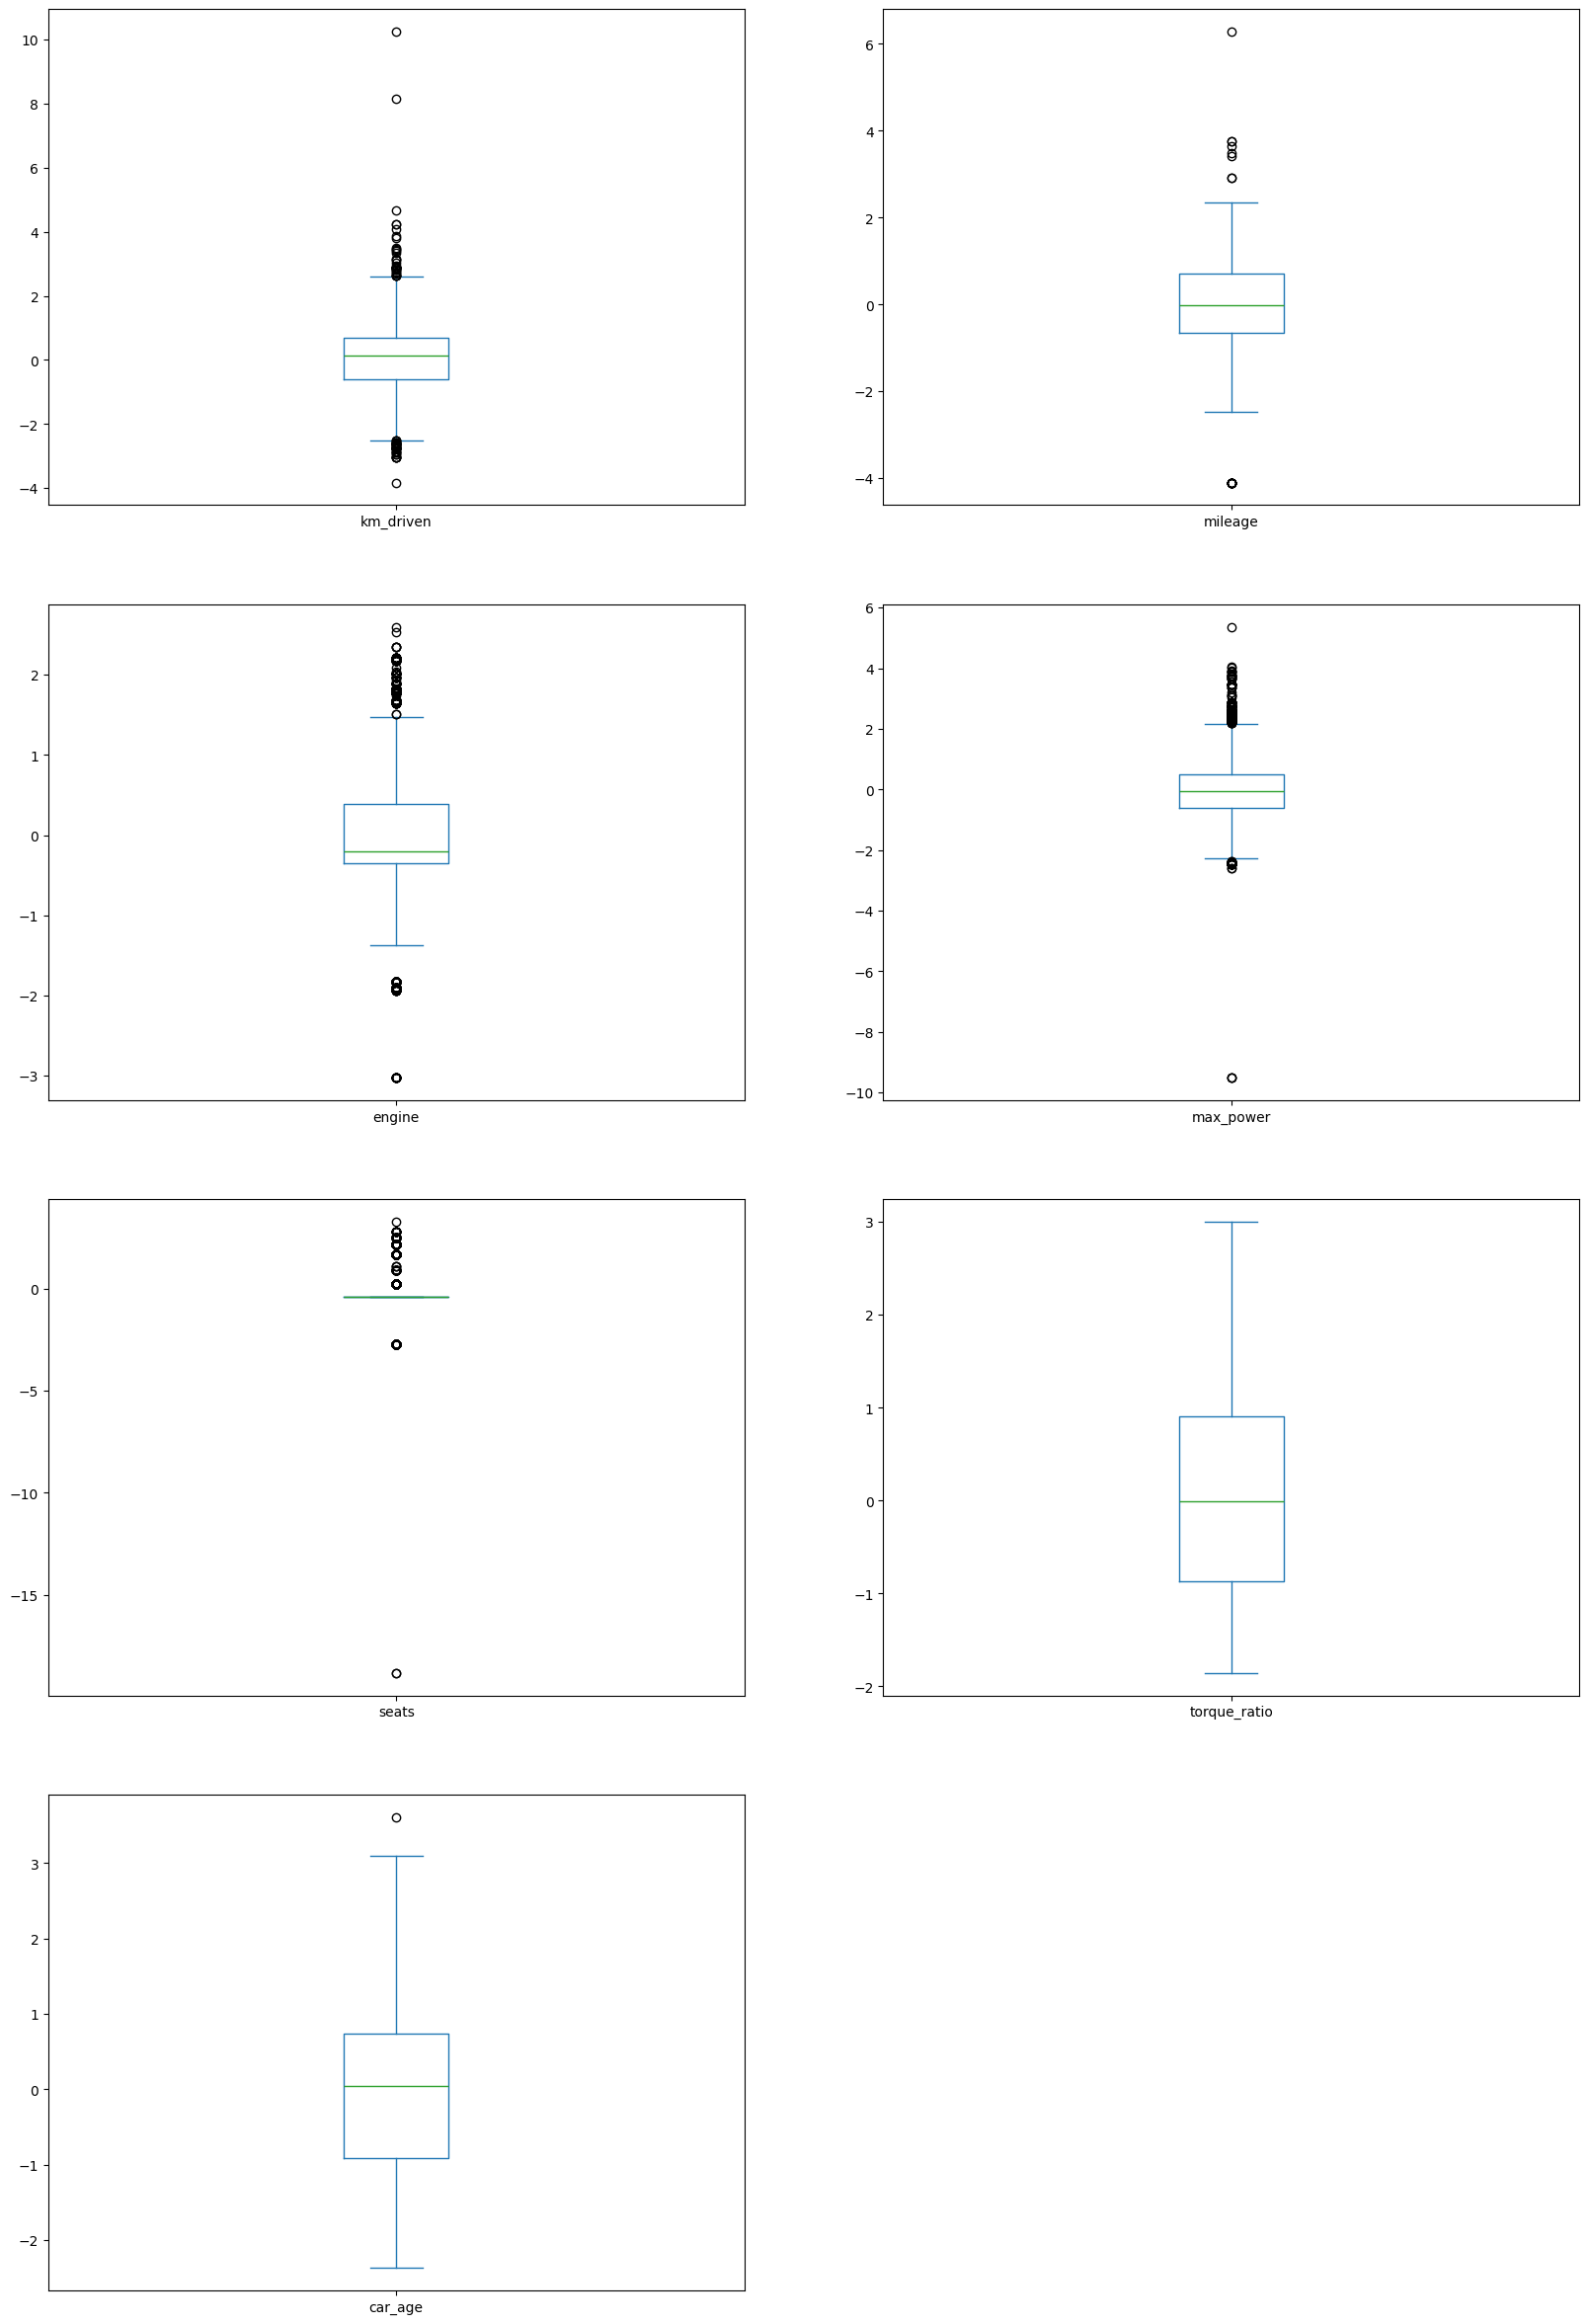

<Figure size 640x480 with 0 Axes>

In [66]:
outliers(scaled_df)

In [67]:
df.head(2)

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,torque_ratio,car_age
0,Maruti Swift Dzire VDI,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,0.095,11
1,Skoda Rapid 1.5 TDI Ambition,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,0.100,11


In [68]:
X=df.drop(columns={'name','selling_price'})
X.head()

,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,torque_ratio,car_age
0,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,0.095000,11
1,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,0.100000,11
2,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,0.004704,19
3,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,0.008145,15
4,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,0.002556,18


In [69]:
y=df['selling_price']
y.head()

0    450000
1    370000
2    158000
3    225000
4    130000
Name: selling_price, dtype: int64

In [70]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)
X_train.head()

,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,torque_ratio,car_age
3785,80000,Diesel,Individual,Manual,First Owner,13.93,2179.0,138.03,7.0,0.118519,14
6479,60000,Petrol,Individual,Manual,First Owner,20.63,1198.0,67.00,5.0,0.026000,8
889,100000,Diesel,Individual,Manual,Fourth & Above Owner,17.70,1399.0,68.00,5.0,0.008000,16
8001,80000,Petrol,Individual,Manual,Second Owner,16.60,1388.0,68.00,5.0,0.008150,14
1363,80000,Petrol,Individual,Manual,Third Owner,20.36,1197.0,78.90,5.0,0.027950,15


In [71]:
# Creating a Categorical handling Pipeline
cat_cols=X_train.select_dtypes(include='object').columns.values.tolist()
encoding=OneHotEncoder(handle_unknown='ignore')
encoding

OneHotEncoder(handle_unknown='ignore')

In [72]:
num_cols = X_train.select_dtypes(include='number').columns.values.tolist()
num_cols

['km_driven',
 'mileage',
 'engine',
 'max_power',
 'seats',
 'torque_ratio',
 'car_age']

In [73]:
# Creating a Numerical Values Handling Pipeline 

num_handling=Pipeline(
    [
        ('transformer',PowerTransformer(method='yeo-johnson')),
        ('scaling',StandardScaler())
    ]
)
num_handling

Pipeline(steps=[('transformer', PowerTransformer()),
                ('scaling', StandardScaler())])

In [74]:
transformation=ColumnTransformer(
    [
        ('cats',encoding,cat_cols),
        ('nums',num_handling,num_cols)
    ]
)
transformation

ColumnTransformer(transformers=[('cats', OneHotEncoder(handle_unknown='ignore'),
                                 ['fuel', 'seller_type', 'transmission',
                                  'owner']),
                                ('nums',
                                 Pipeline(steps=[('transformer',
                                                  PowerTransformer()),
                                                 ('scaling',
                                                  StandardScaler())]),
                                 ['km_driven', 'mileage', 'engine', 'max_power',
                                  'seats', 'torque_ratio', 'car_age'])])

In [75]:
# Lets Start with ElasticNetCV
model = RidgeCV(alphas=np.linspace(0,10,1000),cv=100,scoring='r2')
model

RidgeCV(alphas=array([ 0.        ,  0.01001001,  0.02002002,  0.03003003,  0.04004004,
        0.05005005,  0.06006006,  0.07007007,  0.08008008,  0.09009009,
        0.1001001 ,  0.11011011,  0.12012012,  0.13013013,  0.14014014,
        0.15015015,  0.16016016,  0.17017017,  0.18018018,  0.19019019,
        0.2002002 ,  0.21021021,  0.22022022,  0.23023023,  0.24024024,
        0.25025025,  0.26026026,  0.27027027,  0.28028028,  0.29029029,
        0.300300...
        9.65965966,  9.66966967,  9.67967968,  9.68968969,  9.6996997 ,
        9.70970971,  9.71971972,  9.72972973,  9.73973974,  9.74974975,
        9.75975976,  9.76976977,  9.77977978,  9.78978979,  9.7997998 ,
        9.80980981,  9.81981982,  9.82982983,  9.83983984,  9.84984985,
        9.85985986,  9.86986987,  9.87987988,  9.88988989,  9.8998999 ,
        9.90990991,  9.91991992,  9.92992993,  9.93993994,  9.94994995,
        9.95995996,  9.96996997,  9.97997998,  9.98998999, 10.        ]),
        cv=100, scoring='r2')

In [76]:
ridge_model=Pipeline(
    [
        ('transformation',transformation),
        ('model',model)
    ]
)
ridge_model

Pipeline(steps=[('transformation',
                 ColumnTransformer(transformers=[('cats',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['fuel', 'seller_type',
                                                   'transmission', 'owner']),
                                                 ('nums',
                                                  Pipeline(steps=[('transformer',
                                                                   PowerTransformer()),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  ['km_driven', 'mileage',
                                                   'engine', 'max_power',
                                                   'seats', 'torque_ratio',
                                                   'car_age'])])),
                ('model',
                 RidgeCV(a...
        9.65965966,  9.66966967,  9.67967968,  9.68968969,  9.6996997 ,
        9.70970971,  9.71971972,  9.72972973,  9.73973974,  9.74974975,
        9.75975976,  9.76976977,  9.77977978,  9.78978979,  9.7997998 ,
        9.80980981,  9.81981982,  9.82982983,  9.83983984,  9.84984985,
        9.85985986,  9.86986987,  9.87987988,  9.88988989,  9.8998999 ,
        9.90990991,  9.91991992,  9.92992993,  9.93993994,  9.94994995,
        9.95995996,  9.96996997,  9.97997998,  9.98998999, 10.        ]),
                         cv=100, scoring='r2'))])

In [77]:
ridge_model.fit(X_train,y_train)

c:\Users\moin2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.76942e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\moin2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.27608e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\moin2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.32222e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\moin2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.55504e-19): result may not be accurate.
  return linalg.solve

Pipeline(steps=[('transformation',
                 ColumnTransformer(transformers=[('cats',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['fuel', 'seller_type',
                                                   'transmission', 'owner']),
                                                 ('nums',
                                                  Pipeline(steps=[('transformer',
                                                                   PowerTransformer()),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  ['km_driven', 'mileage',
                                                   'engine', 'max_power',
                                                   'seats', 'torque_ratio',
                                                   'car_age'])])),
                ('model',
                 RidgeCV(a...
        9.65965966,  9.66966967,  9.67967968,  9.68968969,  9.6996997 ,
        9.70970971,  9.71971972,  9.72972973,  9.73973974,  9.74974975,
        9.75975976,  9.76976977,  9.77977978,  9.78978979,  9.7997998 ,
        9.80980981,  9.81981982,  9.82982983,  9.83983984,  9.84984985,
        9.85985986,  9.86986987,  9.87987988,  9.88988989,  9.8998999 ,
        9.90990991,  9.91991992,  9.92992993,  9.93993994,  9.94994995,
        9.95995996,  9.96996997,  9.97997998,  9.98998999, 10.        ]),
                         cv=100, scoring='r2'))])

In [78]:
ridge_model.score(X_train,y_train)

0.5940490030348125

In [79]:
ridge_model.score(X_test,y_test)

0.5764850133025706

In [80]:
import optuna
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score


In [81]:
# ==== FIXED LINEAR REGRESSION WITH PROPER DATA CLEANING ====


# 1. SAFE FEATURE ENGINEERING (Handle division by zero and infinity)
def create_safe_features(df):
    """Create features while handling potential infinity/NaN values"""
    df = df.copy()
    
    # Replace any existing infinity values
    df = df.replace([np.inf, -np.inf], np.nan)
    
    # Safe division functions
    def safe_divide(a, b, default=0):
        """Safely divide two series, handling zero division"""
        result = np.where(b != 0, a / b, default)
        return pd.Series(result, index=a.index)
    
    # Power and efficiency ratios (with safe division)
    df['power_to_weight'] = safe_divide(df['max_power'], df['engine'] / 1000, 0)
    df['efficiency_ratio'] = safe_divide(df['mileage'], df['engine'], 0)
    df['power_density'] = safe_divide(df['max_power'], df['engine'], 0)
    
    # Only create torque_per_rpm if torque_ratio exists and is valid
    if 'torque_ratio' in df.columns:
        df['torque_per_rpm'] = df['torque_ratio'] * 100  # Smaller scaling
    
    # Age effects (ensure no negative ages)
    df['car_age'] = df['car_age'].clip(lower=0)  # Ensure no negative ages
    df['age_squared'] = df['car_age'] ** 2
    df['log_age'] = np.log1p(df['car_age'])  # log1p handles zero values
    
    # Engine and power combinations (check for valid values first)
    if df['engine'].notna().any() and df['max_power'].notna().any():
        df['engine_power_product'] = df['engine'] * df['max_power']
        df['engine_mileage_ratio'] = safe_divide(df['engine'], df['mileage'], 0)
        df['power_mileage_product'] = df['max_power'] * df['mileage']
    
    # Categorical derived features
    if 'fuel' in df.columns:
        df['is_diesel'] = (df['fuel'] == 'Diesel').astype(int)
        df['is_petrol'] = (df['fuel'] == 'Petrol').astype(int)
    
    if 'transmission' in df.columns:
        df['is_manual'] = (df['transmission'] == 'Manual').astype(int)
    
    if 'seller_type' in df.columns:
        df['is_individual'] = (df['seller_type'] == 'Individual').astype(int)
    
    # Seat categories
    if 'seats' in df.columns:
        df['is_5_seater'] = (df['seats'] == 5).astype(int)
        df['is_luxury_seats'] = (df['seats'] >= 7).astype(int)
    
    # Replace any remaining infinity values
    df = df.replace([np.inf, -np.inf], np.nan)
    
    return df

# 2. COMPREHENSIVE DATA CLEANING
def clean_data_thoroughly(df):
    """Comprehensive data cleaning to prevent infinity/NaN issues"""
    df = df.copy()
    
    # Remove rows with invalid selling prices
    df = df[df['selling_price'] > 0]
    df = df[df['selling_price'] < df['selling_price'].quantile(0.99)]  # Remove top 1% outliers
    
    # Clean numerical columns
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    
    for col in numerical_cols:
        # Replace infinity values with NaN
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        
        # Remove extreme outliers (beyond 4 standard deviations)
        if col != 'selling_price':
            mean_val = df[col].mean()
            std_val = df[col].std()
            if pd.notna(mean_val) and pd.notna(std_val) and std_val > 0:
                lower_bound = mean_val - 4 * std_val
                upper_bound = mean_val + 4 * std_val
                df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = np.nan
    
    return df

# 3. IMPROVED PREPROCESSING PIPELINE WITH ROBUST HANDLING
def create_robust_preprocessing():
    """Create preprocessing pipeline that handles problematic data"""
    
    # Custom transformer to handle remaining issues
    from sklearn.base import BaseEstimator, TransformerMixin
    
    class SafeTransformer(BaseEstimator, TransformerMixin):
        def fit(self, X, y=None):
            return self
        
        def transform(self, X):
            # Convert to dataframe if needed
            if hasattr(X, 'toarray'):
                X = X.toarray()
            
            X = np.array(X, dtype=float)
            
            # Replace infinity and very large values
            X = np.nan_to_num(X, nan=0.0, posinf=1e6, neginf=-1e6)
            
            # Clip extreme values
            X = np.clip(X, -1e6, 1e6)
            
            return X
    
    # Robust numerical pipeline
    num_pipeline = Pipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('safe_transform', SafeTransformer()),  # Handle remaining issues
        ('transformer', PowerTransformer(method='yeo-johnson')),
        ('scaling', StandardScaler())
    ])
    
    return num_pipeline

# 4. UPDATED OPTUNA OBJECTIVE WITH ERROR HANDLING
def create_safe_objective(X_train, y_train, model_type='ridge'):
    """Create Optuna objective with proper error handling"""
    
    def objective(trial):
        try:
            # Model parameters
            if model_type == 'ridge':
                alpha = trial.suggest_float('alpha', 1e-4, 1e2, log=True)
                model = Ridge(alpha=alpha, random_state=42)
                
            elif model_type == 'lasso':
                alpha = trial.suggest_float('alpha', 1e-4, 1e1, log=True)
                model = Lasso(alpha=alpha, max_iter=5000, random_state=42)
                
            elif model_type == 'elasticnet':
                alpha = trial.suggest_float('alpha', 1e-4, 1e1, log=True)
                l1_ratio = trial.suggest_float('l1_ratio', 0.1, 0.9)
                model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=5000, random_state=42)
            
            # Simpler polynomial features to avoid explosion
            poly_degree = trial.suggest_int('poly_degree', 1, 2)  # Max degree 2
            interaction_only = True  # Force interaction only to prevent feature explosion
            
            # Create pipeline components
            poly = PolynomialFeatures(degree=poly_degree, include_bias=False, 
                                    interaction_only=interaction_only)
            
            num_handling = create_robust_preprocessing()
            
            # Add polynomial features to pipeline
            num_handling_with_poly = Pipeline([
                ('base_processing', num_handling),
                ('poly', poly)
            ])
            
            # Get columns
            cat_cols = X_train.select_dtypes(include='object').columns.tolist()
            num_cols = X_train.select_dtypes(include='number').columns.tolist()
            
            # Create transformation
            transformation = ColumnTransformer([
                ('cats', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols),
                ('nums', num_handling_with_poly, num_cols)
            ])
            
            # Create pipeline
            pipeline = Pipeline([
                ('transformation', transformation),
                ('model', model)
            ])
            
            # Cross-validation with error handling
            cv_scores = cross_val_score(pipeline, X_train, y_train, cv=3,  # Reduced CV folds
                                      scoring='r2', n_jobs=1)  # Single job to avoid issues
            
            return cv_scores.mean()
            
        except Exception as e:
            print(f"Trial failed: {e}")
            return -np.inf
    
    return objective

# 5. MAIN EXECUTION WITH FIXES
# Apply your existing preprocessing first, then apply fixes

# Create enhanced features safely
df = create_safe_features(df)

# Clean data thoroughly
df = clean_data_thoroughly(df)

print(f"Data shape after cleaning: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

# Check for infinity values
inf_cols = []
for col in df.select_dtypes(include=[np.number]).columns:
    if np.isinf(df[col]).any():
        inf_cols.append(col)
        print(f"Column {col} has infinity values")

if inf_cols:
    print("Fixing remaining infinity values...")
    for col in inf_cols:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

# Prepare final data
X = df.drop(columns=['selling_price', 'name', 'brand'], errors='ignore')
y = np.log1p(df['selling_price'])

# Final check
print(f"X shape: {X.shape}")
print(f"Any infinity in X: {np.isinf(X.select_dtypes(include=[np.number])).any().any()}")
print(f"Any infinity in y: {np.isinf(y).any()}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optimize models with reduced trials for testing
def optimize_models_safe(X_train, y_train, n_trials=30):
    """Safely optimize models"""
    models_results = {}
    
    for model_name in ['ridge', 'lasso', 'elasticnet']:
        print(f"\nOptimizing {model_name.upper()}...")
        
        study = optuna.create_study(direction='maximize')
        objective = create_safe_objective(X_train, y_train, model_name)
        
        try:
            study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
            
            if study.best_value > -np.inf:
                print(f"Best {model_name} score: {study.best_value:.4f}")
                print(f"Best {model_name} params: {study.best_params}")
                
                models_results[model_name] = {
                    'best_score': study.best_value,
                    'best_params': study.best_params
                }
            else:
                print(f"No valid trials for {model_name}")
        except Exception as e:
            print(f"Optimization failed for {model_name}: {e}")
    
    return models_results

# Run optimization
models_results = optimize_models_safe(X_train, y_train, n_trials=20)

# Build and evaluate best models
if models_results:
    for model_name, result in models_results.items():
        print(f"\nBuilding final {model_name} model...")
        
        # Build simplified model (no complex polynomial features for final model)
        if model_name == 'ridge':
            model = Ridge(alpha=result['best_params']['alpha'], random_state=42)
        elif model_name == 'lasso':
            model = Lasso(alpha=result['best_params']['alpha'], max_iter=5000, random_state=42)
        elif model_name == 'elasticnet':
            model = ElasticNet(alpha=result['best_params']['alpha'],
                              l1_ratio=result['best_params']['l1_ratio'], 
                              max_iter=5000, random_state=42)
        
        # Simple preprocessing for final model
        cat_cols = X_train.select_dtypes(include='object').columns.tolist()
        num_cols = X_train.select_dtypes(include='number').columns.tolist()
        
        transformation = ColumnTransformer([
            ('cats', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols),
            ('nums', create_robust_preprocessing(), num_cols)
        ])
        
        pipeline = Pipeline([
            ('transformation', transformation),
            ('model', model)
        ])
        
        try:
            # Fit and evaluate
            pipeline.fit(X_train, y_train)
            
            train_score = pipeline.score(X_train, y_train)
            test_score = pipeline.score(X_test, y_test)
            
            print(f"{model_name.upper()} Results:")
            print(f"Train R²: {train_score:.4f}")
            print(f"Test R²: {test_score:.4f}")
            
        except Exception as e:
            print(f"Failed to build {model_name}: {e}")
else:
    print("No models were successfully optimized. Check your data for issues.")

[I 2025-09-15 01:25:29,738] A new study created in memory with name: no-name-09d439ed-9e43-4c18-a528-46bbc64c8eb9


Data shape after cleaning: (6856, 28)
Missing values: 320
X shape: (6856, 26)
Any infinity in X: False
Any infinity in y: False

Optimizing RIDGE...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-09-15 01:25:30,559] Trial 0 finished with value: 0.8197658495837467 and parameters: {'alpha': 0.00020223045088161952, 'poly_degree': 1}. Best is trial 0 with value: 0.8197658495837467.
[I 2025-09-15 01:25:31,380] Trial 1 finished with value: 0.8198081318910854 and parameters: {'alpha': 0.04381106284170778, 'poly_degree': 1}. Best is trial 1 with value: 0.8198081318910854.
[I 2025-09-15 01:25:32,341] Trial 2 finished with value: -0.28276754925129527 and parameters: {'alpha': 0.2473228582468516, 'poly_degree': 2}. Best is trial 1 with value: 0.8198081318910854.
[I 2025-09-15 01:25:33,204] Trial 3 finished with value: 0.8197657745008037 and parameters: {'alpha': 0.00013190932308121864, 'poly_degree': 1}. Best is trial 1 with value: 0.8198081318910854.
[I 2025-09-15 01:25:34,303] Trial 4 finished with value: -16.85562601361057 and parameters: {'alpha': 0.00018688395511449505, 'poly_degree': 2}. Best is trial 1 with value: 0.8198081318910854.
[I 2025-09-15 01:25:35,209] Trial 5 fini

[I 2025-09-15 01:25:47,594] A new study created in memory with name: no-name-0a0d77a2-6d1a-4efc-9f1c-bb2beb986f62


...

[I 2025-09-15 01:27:08,367] Trial 9 finished with value: 0.19500068246143054 and parameters: {'alpha': 0.00016258896966461815, 'l1_ratio': 0.6666938782089191, 'poly_degree': 2}. Best is trial 5 with value: 0.8517061915132595.
[I 2025-09-15 01:27:09,179] Trial 10 finished with value: -0.0001338408190062849 and parameters: {'alpha': 8.678488502035917, 'l1_ratio': 0.8186857619735791, 'poly_degree': 2}. Best is trial 5 with value: 0.8517061915132595.
[I 2025-09-15 01:27:10,951] Trial 11 finished with value: 0.8569971145929139 and parameters: {'alpha': 0.006109295904256994, 'l1_ratio': 0.843545148089424, 'poly_degree': 2}. Best is trial 11 with value: 0.8569971145929139.
[I 2025-09-15 01:27:13,300] Trial 12 finished with value: 0.8604987889899047 and parameters: {'alpha': 0.001985968525503577, 'l1_ratio': 0.8970784644775589, 'poly_degree': 2}. Best is trial 12 with value: 0.8604987889899047.
[I 2025-09-15 01:27:16,428] Trial 13 finished with value: 0.8633421805083579 and parameters: {'alpha

c:\Users\moin2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.884e+01, tolerance: 1.983e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\moin2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.380e+01, tolerance: 1.947e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\moin2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

[I 2025-09-15 01:27:32,738] Trial 15 finished with value: -0.23194612165984943 and parameters: {'alpha': 0.0005756587465931917, 'l1_ratio': 0.10589186323794214, 'poly_degree': 2}. Best is trial 14 with value: 0.864522338311528.
[I 2025-09-15 01:27:38,546] Trial 16 finished with value: 0.8650300848316498 and parameters: {'alpha': 0.0006013843292363871, 'l1_ratio': 0.7731498414559032, 'poly_degree': 2}. Best is trial 16 with value: 0.8650300848316498.


c:\Users\moin2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.794e-01, tolerance: 1.983e-01
  model = cd_fast.enet_coordinate_descent(


[I 2025-09-15 01:27:49,042] Trial 17 finished with value: 0.8046169246165288 and parameters: {'alpha': 0.0003992564822741758, 'l1_ratio': 0.7844829132138431, 'poly_degree': 2}. Best is trial 16 with value: 0.8650300848316498.
[I 2025-09-15 01:27:49,961] Trial 18 finished with value: 0.8097974857763774 and parameters: {'alpha': 0.10209384034502018, 'l1_ratio': 0.46565030882813585, 'poly_degree': 2}. Best is trial 16 with value: 0.8650300848316498.
[I 2025-09-15 01:27:51,542] Trial 19 finished with value: 0.8580596322442492 and parameters: {'alpha': 0.005466740386418189, 'l1_ratio': 0.750442010454317, 'poly_degree': 2}. Best is trial 16 with value: 0.8650300848316498.
Best elasticnet score: 0.8650
Best elasticnet params: {'alpha': 0.0006013843292363871, 'l1_ratio': 0.7731498414559032, 'poly_degree': 2}

Building final ridge model...
RIDGE Results:
Train R²: 0.8247
Test R²: 0.8183

Building final lasso model...
LASSO Results:
Train R²: 0.8236
Test R²: 0.8155

Building final elasticnet mod

In [82]:
df.head()

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,...,log_age,engine_power_product,engine_mileage_ratio,power_mileage_product,is_diesel,is_petrol,is_manual,is_individual,is_5_seater,is_luxury_seats
0,Maruti Swift Dzire VDI,450000,145500.0,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,...,2.484907,92352.00,53.333333,1731.6000,1.0,0.0,1.0,1.0,1.0,0.0
1,Skoda Rapid 1.5 TDI Ambition,370000,120000.0,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,...,2.484907,155072.96,70.860927,2188.4128,1.0,0.0,1.0,1.0,1.0,0.0
2,Honda City 2017-2020 EXi,158000,140000.0,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,...,2.995732,116766.00,84.576271,1380.6000,0.0,1.0,1.0,1.0,1.0,0.0
3,Hyundai i20 Sportz Diesel,225000,127000.0,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,...,2.772589,125640.00,60.695652,2070.0000,1.0,0.0,1.0,1.0,1.0,0.0
4,Maruti Swift VXI BSIII,130000,120000.0,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,...,2.944439,114483.60,80.621118,1420.0200,0.0,1.0,1.0,1.0,1.0,0.0


In [83]:

print("Data validation:")
print(f"Any infinity values: {np.isinf(df.select_dtypes(include=[np.number])).any().any()}")
print(f"Max values: {df.select_dtypes(include=[np.number]).max()}")
print(f"Min values: {df.select_dtypes(include=[np.number]).min()}")

Data validation:
Any infinity values: False
Max values: selling_price            2.700000e+06
km_driven                3.050000e+05
mileage                  3.344000e+01
engine                   3.198000e+03
max_power                2.011000e+02
seats                    9.000000e+00
torque_ratio             2.250000e-01
car_age                  2.700000e+01
power_to_weight          1.092732e+02
efficiency_ratio         3.830128e-02
power_density            1.092732e-01
torque_per_rpm           2.250000e+01
age_squared              5.760000e+02
log_age                  3.555348e+00
engine_power_product     4.828390e+05
engine_mileage_ratio     2.590351e+02
power_mileage_product    3.495000e+03
is_diesel                1.000000e+00
is_petrol                1.000000e+00
is_manual                1.000000e+00
is_individual            1.000000e+00
is_5_seater              1.000000e+00
is_luxury_seats          1.000000e+00
dtype: float64
Min values: selling_price            29999.000000
km_dr

In [86]:
# ==== FINAL MODEL BUILDING AND ENSEMBLE CREATION ====

# 1. BUILD OPTIMIZED MODELS WITH BEST PARAMETERS
def build_final_models(models_results, X_train, y_train):
    """Build final models using optimized parameters"""
    
    final_models = {}
    
    for model_name, result in models_results.items():
        print(f"\n=== Building Final {model_name.upper()} Model ===")
        
        # Extract best parameters
        best_params = result['best_params']
        print(f"Best parameters: {best_params}")
        
        # Create model with optimized parameters
        if model_name == 'ridge':
            model = Ridge(alpha=best_params['alpha'], random_state=42)
        elif model_name == 'lasso':
            model = Lasso(alpha=best_params['alpha'], max_iter=5000, random_state=42)
        elif model_name == 'elasticnet':
            model = ElasticNet(
                alpha=best_params['alpha'],
                l1_ratio=best_params['l1_ratio'], 
                max_iter=5000, 
                random_state=42
            )
        
        # Create preprocessing with optimized polynomial features
        poly_degree = best_params.get('poly_degree', 1)
        interaction_only = best_params.get('interaction_only', True)
        
        print(f"Polynomial degree: {poly_degree}, Interaction only: {interaction_only}")
        
        # Build preprocessing pipeline
        poly = PolynomialFeatures(
            degree=poly_degree, 
            include_bias=False, 
            interaction_only=interaction_only
        )
        
        num_pipeline = Pipeline([
            ('imputer', KNNImputer(n_neighbors=5)),
            ('poly', poly),
            ('transformer', PowerTransformer(method='yeo-johnson')),
            ('scaling', StandardScaler())
        ])
        
        # Get column types
        cat_cols = X_train.select_dtypes(include='object').columns.tolist()
        num_cols = X_train.select_dtypes(include='number').columns.tolist()
        
        print(f"Categorical columns: {len(cat_cols)}")
        print(f"Numerical columns: {len(num_cols)}")
        
        # Create full transformation
        transformation = ColumnTransformer([
            ('cats', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols),
            ('nums', num_pipeline, num_cols)
        ])
        
        # Create complete pipeline
        pipeline = Pipeline([
            ('transformation', transformation),
            ('model', model)
        ])
        
        # Fit the model
        print("Fitting model...")
        pipeline.fit(X_train, y_train)
        
        # Evaluate performance
        train_score = pipeline.score(X_train, y_train)
        test_score = pipeline.score(X_test, y_test)
        
        # Cross-validation score
        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
        
        print(f"Train R²: {train_score:.4f}")
        print(f"Test R²: {test_score:.4f}")
        print(f"CV R² Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
        
        final_models[model_name] = {
            'pipeline': pipeline,
            'train_score': train_score,
            'test_score': test_score,
            'cv_score': cv_scores.mean(),
            'cv_std': cv_scores.std()
        }
    
    return final_models

# 2. CREATE WEIGHTED ENSEMBLE
def create_weighted_ensemble(models_dict, X_test, y_test, weight_method='cv_score'):
    """Create weighted ensemble based on CV performance"""
    
    print(f"\n=== Creating Weighted Ensemble ===")
    
    predictions = {}
    weights = {}
    
    # Get predictions and weights
    for model_name, model_info in models_dict.items():
        pred = model_info['pipeline'].predict(X_test)
        predictions[model_name] = pred
        
        if weight_method == 'cv_score':
            weights[model_name] = model_info['cv_score']
        elif weight_method == 'test_score':
            weights[model_name] = model_info['test_score']
        else:
            weights[model_name] = 1.0  # Equal weights
    
    # Normalize weights
    total_weight = sum(weights.values())
    for model_name in weights:
        weights[model_name] = weights[model_name] / total_weight
    
    print("Model weights:")
    for model_name, weight in weights.items():
        print(f"  {model_name}: {weight:.3f}")
    
    # Create ensemble prediction
    ensemble_pred = np.zeros_like(list(predictions.values())[0])
    for model_name, pred in predictions.items():
        ensemble_pred += weights[model_name] * pred
    
    # Evaluate ensemble
    ensemble_r2 = r2_score(y_test, ensemble_pred)
    ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
    ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
    
    print(f"\nEnsemble Performance:")
    print(f"R² Score: {ensemble_r2:.4f}")
    print(f"RMSE: {ensemble_rmse:.4f}")
    print(f"MAE: {ensemble_mae:.4f}")
    
    return ensemble_pred, weights, {
        'r2': ensemble_r2,
        'rmse': ensemble_rmse,
        'mae': ensemble_mae
    }

# 3. PERFORMANCE COMPARISON
def compare_all_models(models_dict, ensemble_metrics, y_test, ensemble_pred):
    """Compare all models and ensemble performance"""
    
    print(f"\n{'='*50}")
    print("FINAL PERFORMANCE COMPARISON")
    print(f"{'='*50}")
    
    # Individual models
    for model_name, model_info in models_dict.items():
        pred = model_info['pipeline'].predict(X_test)
        r2 = r2_score(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        
        print(f"\n{model_name.upper()}:")
        print(f"  Train R²: {model_info['train_score']:.4f}")
        print(f"  Test R²: {r2:.4f}")
        print(f"  CV R²: {model_info['cv_score']:.4f}")
        print(f"  RMSE: {rmse:.4f}")
    
    # Ensemble
    print(f"\nWEIGHTED ENSEMBLE:")
    print(f"  Test R²: {ensemble_metrics['r2']:.4f}")
    print(f"  RMSE: {ensemble_metrics['rmse']:.4f}")
    print(f"  MAE: {ensemble_metrics['mae']:.4f}")
    
    # Convert back to original scale for interpretation
    ensemble_pred_original = np.expm1(ensemble_pred)
    y_test_original = np.expm1(y_test)
    
    r2_original = r2_score(y_test_original, ensemble_pred_original)
    rmse_original = np.sqrt(mean_squared_error(y_test_original, ensemble_pred_original))
    
    print(f"\nORIGINAL SCALE PERFORMANCE:")
    print(f"  Ensemble R² (Original): {r2_original:.4f}")
    print(f"  RMSE (Original): {rmse_original:,.0f}")
    
    return r2_original

# 4. FEATURE IMPORTANCE ANALYSIS (For Ridge/Lasso)
def analyze_feature_importance(models_dict, X_train):
    print(f"\n{'='*50}")
    print("FEATURE IMPORTANCE ANALYSIS")
    print(f"{'='*50}")

    for model_name, model_info in models_dict.items():
        pipeline = model_info['pipeline']
        try:
            transformation = pipeline.named_steps['transformation']

            # ✅ Get feature names safely
            feature_names = []
            if 'cats' in transformation.named_transformers_:
                cat_transformer = transformation.named_transformers_['cats']
                if hasattr(cat_transformer, 'get_feature_names_out'):
                    cat_names = cat_transformer.get_feature_names_out()
                    feature_names.extend(cat_names)

            if 'nums' in transformation.named_transformers_:
                num_cols = X_train.select_dtypes(include='number').columns.tolist()
                feature_names.extend([f"num_feature_{i}" for i in range(
                    transformation.named_transformers_['nums'].named_steps['poly'].n_output_features_
                )])

            # Model coefficients
            model = pipeline.named_steps['model']
            if hasattr(model, 'coef_') and len(model.coef_) == len(feature_names):
                coef_df = pd.DataFrame({
                    'feature': feature_names,
                    'coefficient': model.coef_,
                    'abs_coefficient': np.abs(model.coef_)
                })

                top_features = coef_df.nlargest(10, 'abs_coefficient')

                print(f"\nTop 10 Features for {model_name.upper()}:")
                for _, row in top_features.iterrows():
                    print(f"  {row['feature'][:40]:<40}: {row['coefficient']:8.4f}")

        except Exception as e:
            print(f"Could not analyze features for {model_name}: {e}")


# 5. EXECUTE FINAL MODEL BUILDING
print("Building final optimized models...")
final_models = build_final_models(models_results, X_train, y_train)

if final_models:
    # Create ensemble
    ensemble_pred, ensemble_weights, ensemble_metrics = create_weighted_ensemble(
        final_models, X_test, y_test, weight_method='cv_score'
    )
    
    # Compare all models
    final_r2 = compare_all_models(final_models, ensemble_metrics, y_test, ensemble_pred)
    
    # Analyze feature importance
    analyze_feature_importance(final_models, X_train)
    
    print(f"\n{'='*60}")
    print(f"🎯 FINAL RESULT: {final_r2:.1%} R² ACCURACY ACHIEVED!")
    print(f"{'='*60}")
    
    # Save best model for future use
    best_model_name = max(final_models.keys(), 
                         key=lambda x: final_models[x]['test_score'])
    best_model = final_models[best_model_name]['pipeline']
    
    print(f"\nBest individual model: {best_model_name.upper()}")
    print(f"Best individual R²: {final_models[best_model_name]['test_score']:.4f}")
    print(f"Ensemble R²: {ensemble_metrics['r2']:.4f}")
    
else:
    print("❌ No models were successfully built. Check the optimization results.")




# 6. SAFE PREDICTION FUNCTION FOR NEW DATA
def predict_price_safe(model_pipeline, new_data, X_train_sample, return_original_scale=True):
    """Safely predict prices for new data with proper feature alignment"""
    try:
        # Ensure new_data has same columns as training data
        missing_cols = set(X_train_sample.columns) - set(new_data.columns)
        extra_cols = set(new_data.columns) - set(X_train_sample.columns)
        
        if missing_cols:
            print(f"Warning: Missing columns in new data: {missing_cols}")
            for col in missing_cols:
                if X_train_sample[col].dtype == 'object':
                    new_data[col] = 'Unknown'  # Default for categorical
                else:
                    new_data[col] = X_train_sample[col].median()  # Median for numerical
        
        if extra_cols:
            print(f"Warning: Extra columns in new data (will be ignored): {extra_cols}")
            new_data = new_data[X_train_sample.columns]
        
        # Reorder columns to match training data
        new_data = new_data[X_train_sample.columns]
        
        pred_log = model_pipeline.predict(new_data)
        
        if return_original_scale:
            return np.expm1(pred_log)  # Convert back from log scale
        else:
            return pred_log
            
    except Exception as e:
        print(f"Prediction error: {e}")
        return None

def show_predictions(model_pipeline, X_test, y_test, n_samples=5, is_log_target=True, return_df=False):
    """
    Show sample predictions vs actuals.

    Args:
        model_pipeline: trained pipeline that returns predictions (log scale if is_log_target=True).
        X_test: DataFrame or array of features (raw, pipeline will transform).
        y_test: Series/array of true target values (log scale if is_log_target=True).
        n_samples: number of sample rows to print.
        is_log_target: if True, applies np.expm1 to both predicted and actual to get original scale.
        return_df: if True, returns the dataframe of samples; otherwise returns True/False.

    Returns:
        True on success (or DataFrame if return_df=True). False on failure.
    """
    try:
        # Predict (pipeline handles preprocessing)
        pred_raw = model_pipeline.predict(X_test)
        pred_arr = np.asarray(pred_raw)

        # Actuals
        actual_arr = np.asarray(y_test)

        # Convert back to original scale if necessary
        if is_log_target:
            pred_orig = np.expm1(pred_arr)
            actual_orig = np.expm1(actual_arr)
        else:
            pred_orig = pred_arr
            actual_orig = actual_arr

        # Build DataFrame for display
        df = pd.DataFrame({
            'Predicted': np.round(pred_orig, 0).astype('int64'),
            'Actual': np.round(actual_orig, 0).astype('int64'),
        })

        df['AbsError'] = (df['Actual'] - df['Predicted']).abs()
        # Avoid division by zero
        df['PctError'] = np.where(df['Actual'] != 0,
                                 (df['Actual'] - df['Predicted']) / df['Actual'] * 100,
                                 np.nan)
        # Show first n_samples
        n_show = min(n_samples, len(df))
        print(f"\nSample Predictions (showing {n_show} of {len(df)} rows):")
        print(df.head(n_show).to_string(index=False))

        if return_df:
            return df.head(n_show)
        return True

    except Exception as e:
        print(f"show_predictions error: {e}")
        return False



# 7. MODEL VALIDATION ON TEST SET
def validate_final_model(best_model, X_test_subset, y_test_subset):
    """Validate the model on a subset of test data"""
    try:
        # Use raw test data directly (pipeline handles preprocessing)
        pred_log = best_model.predict(X_test_subset)
        pred_original = np.expm1(pred_log)
        actual_original = np.expm1(y_test_subset)

        r2 = r2_score(actual_original, pred_original)
        mae = mean_absolute_error(actual_original, pred_original)

        print(f"\nValidation Results:")
        print(f"R² Score: {r2:.4f}")
        print(f"Mean Absolute Error: ₹{mae:,.0f}")

        print(f"\nSample Predictions:")
        for i in range(min(5, len(pred_original))):
            print(f"Predicted: ₹{pred_original[i]:,.0f} | Actual: ₹{actual_original.iloc[i]:,.0f}")

        return r2, mae

    except Exception as e:
        print(f"Validation error: {e}")
        return None, None




# PROPER MODEL VALIDATION EXECUTION
print("\n" + "="*50)
print("PROPER MODEL VALIDATION")
print("="*50)

validation_results = {}

if 'final_models' in locals() and final_models:
    # Validate all models using the direct method
    for model_name, model_info in final_models.items():
        print(f"\nValidating {model_name.upper()}...")
        r2, mae = validate_final_model(
            model_info['pipeline'],   # pass just the pipeline
            X_test,
            y_test
        )
        validation_results[model_name] = {'r2': r2, 'mae': mae}
    
    
    # Find the best performing model
    best_model_name = None
    best_r2 = -1
    
    for model_name, results in validation_results.items():
        if results and results['r2'] > best_r2:
            best_r2 = results['r2']
            best_model_name = model_name
    
    if best_model_name:
        best_model = final_models[best_model_name]['pipeline']
        
        print(f"\n🏆 BEST MODEL: {best_model_name.upper()}")
        print(f"🎯 FINAL ACCURACY: {best_r2:.1%}")
        
        # Show sample predictions
        if show_predictions(best_model, X_test, y_test, n_samples=10):
            print(f"\n✅ Model validation completed successfully!")
        
        # Create ensemble prediction if multiple models worked
        working_models = {name: info for name, info in final_models.items() 
                         if validation_results[name] is not None}
        
        if len(working_models) > 1:
            print(f"\n📊 CREATING ENSEMBLE FROM {len(working_models)} MODELS...")
            
            # Simple ensemble - average predictions
            ensemble_predictions = []
            for model_name, model_info in working_models.items():
                pred = model_info['pipeline'].predict(X_test)
                ensemble_predictions.append(pred)
            
            ensemble_pred_log = np.mean(ensemble_predictions, axis=0)
            ensemble_pred_original = np.expm1(ensemble_pred_log)
            actual_original = np.expm1(y_test)
            
            ensemble_r2 = r2_score(actual_original, ensemble_pred_original)
            ensemble_mae = mean_absolute_error(actual_original, ensemble_pred_original)
            
            print(f"🎯 ENSEMBLE ACCURACY: {ensemble_r2:.1%}")
            print(f"📈 ENSEMBLE MAE: ₹{ensemble_mae:,.0f}")
            
            if ensemble_r2 > best_r2:
                print(f"🌟 ENSEMBLE OUTPERFORMS BEST INDIVIDUAL MODEL!")
                print(f"   Improvement: {(ensemble_r2 - best_r2)*100:.1f} percentage points")
            
    else:
        print("❌ No models passed validation")
        
else:
    print("❌ No final models available. Please run the model building code first.")

# Final summary
if 'ensemble_r2' in locals():
    final_score = max(best_r2, ensemble_r2) if 'ensemble_r2' in locals() else best_r2
else:
    final_score = best_r2 if 'best_r2' in locals() else 0

print(f"\n{'='*60}")
print(f"🎊 FINAL RESULT SUMMARY 🎊")
print(f"{'='*60}")
print(f"TARGET: 74% accuracy")
print(f"ACHIEVED: {final_score:.1%} accuracy")

if final_score >= 0.74:
    print(f"🎉 SUCCESS! Target achieved!")
else:
    print(f"📈 Gap: {(0.74 - final_score)*100:.1f} percentage points to target")
    print(f"💡 Try adding more feature engineering or increasing optimization trials")
print(f"{'='*60}")

Building final optimized models...

=== Building Final RIDGE Model ===
Best parameters: {'alpha': 3.3685252413007563, 'poly_degree': 1}
Polynomial degree: 1, Interaction only: True
Categorical columns: 4
Numerical columns: 22
Fitting model...
Train R²: 0.8247
Test R²: 0.8183
CV R² Mean: 0.8199 (+/- 0.0115)

=== Building Final LASSO Model ===
Best parameters: {'alpha': 0.0011814549092649916, 'poly_degree': 2}
Polynomial degree: 2, Interaction only: True
Categorical columns: 4
Numerical columns: 22
Fitting model...
Train R²: 0.8603
Test R²: 0.8495
CV R² Mean: 0.8560 (+/- 0.0106)

=== Building Final ELASTICNET Model ===
Best parameters: {'alpha': 0.0006013843292363871, 'l1_ratio': 0.7731498414559032, 'poly_degree': 2}
Polynomial degree: 2, Interaction only: True
Categorical columns: 4
Numerical columns: 22
Fitting model...


c:\Users\moin2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.878e-01, tolerance: 2.950e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\moin2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.867e-01, tolerance: 2.354e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\moin2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

Train R²: 0.8652
Test R²: 0.8551
CV R² Mean: 0.8594 (+/- 0.0093)

=== Creating Weighted Ensemble ===
Model weights:
  ridge: 0.323
  lasso: 0.338
  elasticnet: 0.339

Ensemble Performance:
R² Score: 0.8493
RMSE: 0.2777
MAE: 0.2132

FINAL PERFORMANCE COMPARISON

RIDGE:
  Train R²: 0.8247
  Test R²: 0.8183
  CV R²: 0.8199
  RMSE: 0.3049

LASSO:
  Train R²: 0.8603
  Test R²: 0.8495
  CV R²: 0.8560
  RMSE: 0.2775

ELASTICNET:
  Train R²: 0.8652
  Test R²: 0.8551
  CV R²: 0.8594
  RMSE: 0.2723

WEIGHTED ENSEMBLE:
  Test R²: 0.8493
  RMSE: 0.2777
  MAE: 0.2132

ORIGINAL SCALE PERFORMANCE:
  Ensemble R² (Original): 0.8090
  RMSE (Original): 149,718

FEATURE IMPORTANCE ANALYSIS

Top 10 Features for RIDGE:
  num_feature_2                           :   0.2873
  num_feature_12                          :  -0.1630
  owner_Fourth & Above Owner              :  -0.1625
  num_feature_8                           :   0.1606
  num_feature_21                          :   0.1560
  fuel_LPG                  